<a href="https://colab.research.google.com/github/costpetrides/FAIRMODE-WG5/blob/main/mult_idw_no2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import pandas as pd
import netCDF4 as nc
from sklearn.neighbors import BallTree

# ======================================================
# LOAD DATA
# ======================================================
df = pd.read_csv("baseNO2_gridcell_average.csv")

# Bias ratio (multiplicative correction)
df["bias_ratio"] = df["SURF_ug_NO2"] / df["nearest_SURF_ug_NO2"]

dataset = nc.Dataset("EMEP_yearly_2015.nc", "r")

lon = dataset.variables["lon"][:]
lat = dataset.variables["lat"][:]
model = dataset.variables["SURF_ug_NO2"][0, :, :]

# ======================================================
# PREPARE DATA
# ======================================================
cell_points = np.column_stack([
    np.radians(df["nearest_grid_lat"].values),
    np.radians(df["nearest_grid_lon"].values)
])

bias_values = df["bias_ratio"].values

# ======================================================
#  MANUAL PARAMETERS (YOU CONTROL THESE)
# ======================================================
p = 3     # distance decay
k = 2      # number of neighbors

print(f"\nUsing manual parameters: p={p}, k={k}")

# ======================================================
# INTERPOLATION GRID
# ======================================================
lon_mesh, lat_mesh = np.meshgrid(lon, lat)

grid_points = np.column_stack([
    np.radians(lat_mesh.ravel()),
    np.radians(lon_mesh.ravel())
])

# ======================================================
# IDW INTERPOLATION
# ======================================================
tree = BallTree(cell_points, metric="haversine")

dists, idxs = tree.query(grid_points, k=k)

# Avoid division by zero
dists = np.maximum(dists, 1e-12)

# Compute weights
weights = 1 / (dists ** p)
weights /= weights.sum(axis=1, keepdims=True)

# Interpolated bias field
final_bias = np.sum(weights * bias_values[idxs], axis=1)
final_bias = final_bias.reshape(model.shape)

# ======================================================
# SAVE OUTPUT
# ======================================================
out_nc = nc.Dataset("Final_NO2_bias_3_2.nc", "w", format="NETCDF4")

out_nc.createDimension("lat", len(lat))
out_nc.createDimension("lon", len(lon))

lat_var = out_nc.createVariable("lat", "f4", ("lat",))
lon_var = out_nc.createVariable("lon", "f4", ("lon",))
bias_var = out_nc.createVariable("Interpolated_Bias", "f4", ("lat", "lon"))

lat_var[:] = lat
lon_var[:] = lon
bias_var[:, :] = final_bias

out_nc.close()

print("Saved")


Using manual parameters: p=3, k=2
Saved


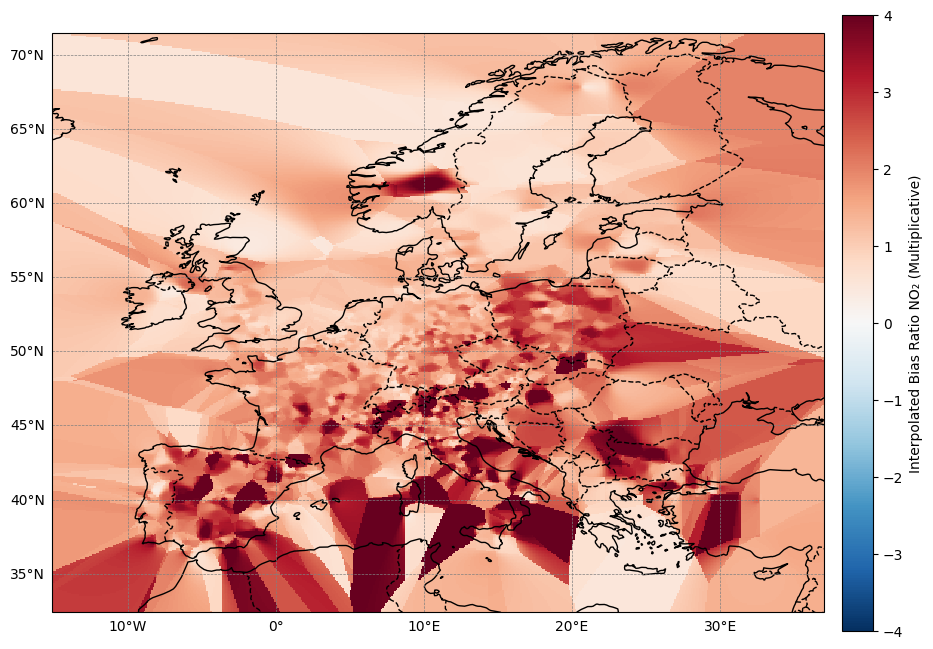

In [16]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# === Load the Interpolated Bias Ratio NetCDF File for NO₂ ===
bias_netcdf_path = "BaseCase_NO2_Y_IDW_MUL.nc"
ds_bias = xr.open_dataset(bias_netcdf_path)

# Extract interpolated bias ratio
interpolated_bias_ratio = ds_bias["Interpolated_Bias"].squeeze().values

# Extract coordinates
lon = ds_bias["lon"].values
lat = ds_bias["lat"].values

# === Define Plot Limits (Adjust if needed) ===
cbar_min = -4  # Set minimum scale for bias ratio
cbar_max = 4   # Set maximum scale for bias ratio

# Create a plot with Cartopy
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the interpolated bias ratio
im = ax.pcolormesh(lon, lat, interpolated_bias_ratio, transform=ccrs.PlateCarree(), cmap="RdBu_r", vmin=cbar_min, vmax=cbar_max, shading='auto')

# Add colorbar
cbar = plt.colorbar(im, orientation="vertical", pad=0.02)
cbar.set_label("Interpolated Bias Ratio NO₂ (Multiplicative)")

# Add country borders and coastlines
ax.add_feature(cfeature.BORDERS, linestyle="--", edgecolor="black", linewidth=1)
ax.coastlines(resolution="50m", linewidth=1)

# Add gridlines and labels for longitude and latitude
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False  # Remove top labels
gl.right_labels = False  # Remove right-side labels

# Set title and labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

# Close dataset
ds_bias.close()

In [17]:

import netCDF4 as nc
import numpy as np

# === Define File Paths ===
original_nc_path = "EMEP_yearly_2015.nc"
bias_ratio_nc_path = "BaseCase_NO2_Y_IDW_MUL.nc"
corrected_nc_path = "BaseCase_Corrected_NO2_Y_MUL.nc"

# === Load the Original Modeled NO₂ NetCDF ===
with nc.Dataset(original_nc_path, "r") as original_nc, nc.Dataset(bias_ratio_nc_path, "r") as bias_nc:

    # Load model coordinates and data
    lon = original_nc.variables["lon"][:]
    lat = original_nc.variables["lat"][:]
    time = original_nc.variables["time"][:]
    no2_original = original_nc.variables["SURF_ug_NO2"][:]

    # Load the interpolated bias ratio
    interpolated_bias_ratio = bias_nc.variables["Interpolated_Bias"][:]

    # === Apply Multiplicative Bias Correction ===
    # Ensure bias ratio does not contain values too close to zero
    min_bias_threshold = 0.1  # Prevent extreme scaling
    interpolated_bias_ratio = np.maximum(interpolated_bias_ratio, min_bias_threshold)

    # Correct NO₂
    no2_corrected = no2_original * interpolated_bias_ratio  # Multiplicative correction

    # === Save the Corrected NO₂ to a New NetCDF File ===
    with nc.Dataset(corrected_nc_path, "w", format="NETCDF4") as new_nc:

        # Create dimensions
        new_nc.createDimension("time", None)
        new_nc.createDimension("lat", lat.shape[0])
        new_nc.createDimension("lon", lon.shape[0])

        # Create variables
        time_var = new_nc.createVariable("time", "f4", ("time",))
        lat_var = new_nc.createVariable("lat", "f4", ("lat",))
        lon_var = new_nc.createVariable("lon", "f4", ("lon",))
        no2_var = new_nc.createVariable("SURF_ug_NO2_corrected", "f4", ("time", "lat", "lon"), fill_value=-9999.0)

        # Copy attributes from the original NO₂ variable
        no2_var.setncatts(original_nc.variables["SURF_ug_NO2"].__dict__)

        # Save data
        time_var[:] = time
        lat_var[:] = lat
        lon_var[:] = lon
        no2_var[:] = no2_corrected  # Store corrected NO₂

print("Multiplicative Bias Correction Completed Successfully!")
print("Corrected NO₂ NetCDF file saved as:", corrected_nc_path)

Multiplicative Bias Correction Completed Successfully!
Corrected NO₂ NetCDF file saved as: BaseCase_Corrected_NO2_Y_MUL.nc


In [18]:

import netCDF4 as nc
import numpy as np
import shutil

# === Define File Paths ===
input_file = "BaseCase_Corrected_NO2_Y_MUL.nc"  # Your original file
output_file = "BaseCase_UoA_NO2_SCA.Cell.Mult.IDW_CORR_YEARLY.nc"  # Renamed final file
jrc_reference_file = "EMEP_yearly_2015.nc"  # JRC reference file

# === Backup Original File Before Modifying ===
shutil.copy(input_file, output_file)

# === Open Original NetCDF and Read Data ===
with nc.Dataset(input_file, "r") as src:

    # Read dimensions
    lon = src.variables["lon"][:]
    lat = src.variables["lat"][:]
    time = src.variables["time"][:]
    o3_data = src.variables["SURF_ug_NO2_corrected"][:]  # Read O3 data

    # Open new NetCDF file for writing with correct dimension order
    with nc.Dataset(output_file, "w", format="NETCDF4") as dst:

        # === Create Dimensions in Correct Order ===
        dst.createDimension("lon", len(lon))
        dst.createDimension("lat", len(lat))
        dst.createDimension("time", None)  # Keep time as unlimited

        # === Create Variables in Correct Order ===
        lon_var = dst.createVariable("lon", "f4", ("lon",))
        lat_var = dst.createVariable("lat", "f4", ("lat",))
        time_var = dst.createVariable("time", "f4", ("time",))
        o3_var = dst.createVariable("SURF_ug_NO2", "f4", ("lon", "lat", "time"), fill_value=-9999.0)

        # === Copy Attributes from Original File ===
        for attr in src.ncattrs():
            dst.setncattr(attr, src.getncattr(attr))

        # === Add Missing Global Attributes ===
        jrc_attributes = {
            "vert_coord": "atmosphere_hybrid_sigma_pressure_coordinate",
            "Conventions": "CF-1.6 for coordinates",
            "model": "EMEP_MSC-W",
            "author_of_run": "UoA",
            "created_date": "20250315",
            "created_hour": "091845.466",
            "lastmodified_date": "20241122",
            "lastmodified_hour": "084815.947",
            "projection": "lon lat",
            "period_type": "fullrun",
            "run_label": "Opensource_Setup_2025",
            "history": "Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_NO2",
            "NCO": "netCDF Operators version 5.0.6 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco)"
        }
        for attr, value in jrc_attributes.items():
            dst.setncattr(attr, value)

        # === Copy Variable Data (Reordered) ===
        lon_var[:] = lon
        lat_var[:] = lat
        time_var[:] = time
        o3_var[:, :, :] = np.transpose(o3_data, (2, 1, 0))  # Reorder from (time, lat, lon) to (lon, lat, time)

print(f" Correction completed! Renamed and fixed NetCDF saved as: {output_file}")

# === Function to Extract NetCDF Structure ===
def get_netcdf_structure(filepath):
    with nc.Dataset(filepath, "r") as dataset:
        structure = {
            "dimensions": {dim: dataset.dimensions[dim].size for dim in dataset.dimensions},
            "variables": {var: dataset.variables[var].dimensions for var in dataset.variables},
            "attributes": {attr: dataset.getncattr(attr) for attr in dataset.ncattrs()}
        }
    return structure

# Extract structures
your_structure = get_netcdf_structure(output_file)
jrc_structure = get_netcdf_structure(jrc_reference_file)

# === Compare Structures ===
print("\n=== DIMENSIONS COMPARISON ===")
print("Your File:", your_structure["dimensions"])
print("JRC File:", jrc_structure["dimensions"])

print("\n=== VARIABLES COMPARISON ===")
print("Your File:", list(your_structure["variables"].keys()))
print("JRC File:", list(jrc_structure["variables"].keys()))

print("\n=== GLOBAL ATTRIBUTES COMPARISON ===")
print("Your File:", your_structure["attributes"])
print("JRC File:", jrc_structure["attributes"])

print(" Final check completed! If all outputs match, your NetCDF is JRC-compliant.")

 Correction completed! Renamed and fixed NetCDF saved as: BaseCase_UoA_NO2_SCA.Cell.Mult.IDW_CORR_YEARLY.nc

=== DIMENSIONS COMPARISON ===
Your File: {'lon': 521, 'lat': 391, 'time': 1}
JRC File: {'time': 1, 'lat': 391, 'lon': 521}

=== VARIABLES COMPARISON ===
Your File: ['lon', 'lat', 'time', 'SURF_ug_NO2']
JRC File: ['time', 'lat', 'lon', 'SURF_ug_PM25_rh50', 'SURF_ug_NO2', 'SURF_ug_O3']

=== GLOBAL ATTRIBUTES COMPARISON ===
Your File: {'vert_coord': 'atmosphere_hybrid_sigma_pressure_coordinate', 'Conventions': 'CF-1.6 for coordinates', 'model': 'EMEP_MSC-W', 'author_of_run': 'UoA', 'created_date': '20250315', 'created_hour': '091845.466', 'lastmodified_date': '20241122', 'lastmodified_hour': '084815.947', 'projection': 'lon lat', 'period_type': 'fullrun', 'run_label': 'Opensource_Setup_2025', 'history': 'Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_NO2', 'NCO': 'netCDF Operators version 5.0.6 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco)'}
JRC File: {'vert_

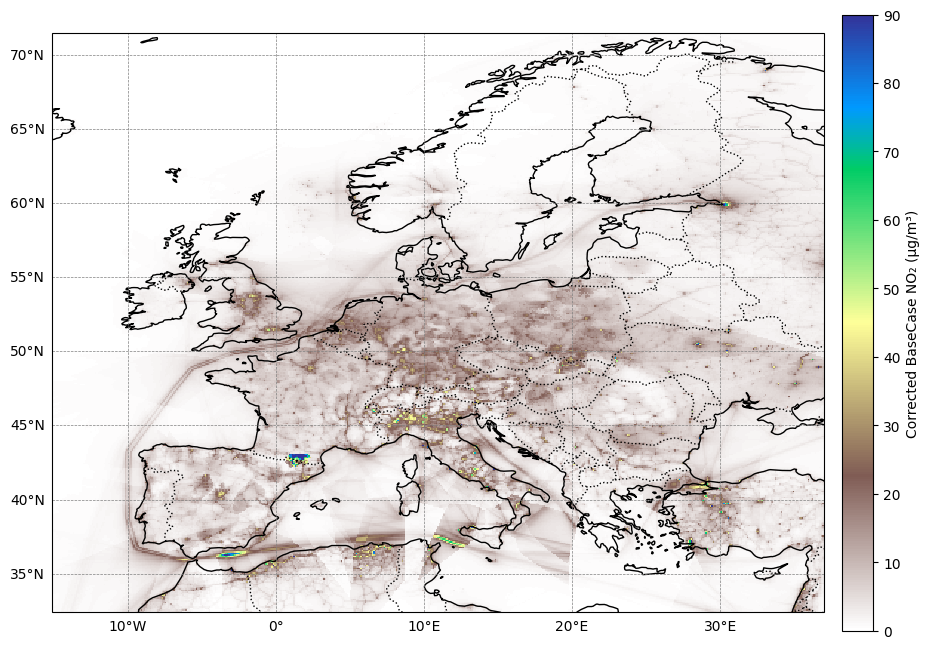

In [19]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# === Load the Corrected NO₂ NetCDF File ===
corrected_netcdf_path = "BaseCase_UoA_NO2_SCA.Cell.Mult.IDW_CORR_YEARLY.nc"
ds_corrected = xr.open_dataset(corrected_netcdf_path)

# Extract corrected NO₂ values
corrected_no2 = ds_corrected["SURF_ug_NO2"].squeeze().values.T

# Extract coordinates
lon = ds_corrected["lon"].values
lat = ds_corrected["lat"].values

# Create a 2D meshgrid for lon & lat
Lon, Lat = np.meshgrid(lon, lat)

# === Define Color Normalization Scale for NO₂ ===
norm = mcolors.Normalize(0, 90)  # Adjust scale for NO₂ concentration range (µg/m³)

# Create a figure with a map projection
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the NO₂ concentration using pcolormesh
mesh = ax.pcolormesh(Lon, Lat, corrected_no2, cmap='terrain_r', shading='auto', transform=ccrs.PlateCarree(), norm=norm)

# Add a colorbar
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label("Corrected BaseCase NO₂ (µg/m³)")

# Add coastlines and borders for context
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Add gridlines and labels for longitude and latitude
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False  # Remove top labels
gl.right_labels = False  # Remove right-side labels

# Set title and labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

# Close dataset
ds_corrected.close()

In [20]:


import netCDF4 as nc
import numpy as np

# === Define File Paths ===
scenario_perturbed_nc_path = "EMEP_yearly_2022.nc"  # Perturbed Scenario NetCDF
bias_residual_nc_path = "BaseCase_NO2_Y_IDW_MUL.nc"  # Interpolated Bias Ratios NetCDF
corrected_scenario_nc_path = "Scenario_Corrected_NO2_MUL.nc"  # Output Corrected Scenario NetCDF

# === Load NetCDF Files ===
with nc.Dataset(scenario_perturbed_nc_path, "r") as scen_nc, \
     nc.Dataset(bias_residual_nc_path, "r") as bias_nc:

    # Load grid and data
    lon = scen_nc.variables["lon"][:]
    lat = scen_nc.variables["lat"][:]
    time = scen_nc.variables["time"][:]

    no2_scenario_perturbed = scen_nc.variables["SURF_ug_NO2"][:]  # Perturbed Scenario NO₂
    interpolated_bias_ratios = bias_nc.variables["Interpolated_Bias"][:]  # Interpolated Bias Ratios (OBS / MOD)

    # === Apply Multiplicative Correction ===
    min_ratio_threshold = 0.1  # Optional: prevent extreme downscaling
    interpolated_bias_ratios = np.maximum(interpolated_bias_ratios, min_ratio_threshold)

    no2_scenario_corrected = no2_scenario_perturbed * interpolated_bias_ratios

    # === Save Corrected Scenario ===
    with nc.Dataset(corrected_scenario_nc_path, "w", format="NETCDF4") as new_nc:

        # Create dimensions
        new_nc.createDimension("time", None)
        new_nc.createDimension("lat", lat.shape[0])
        new_nc.createDimension("lon", lon.shape[0])

        # Create variables
        time_var = new_nc.createVariable("time", "f4", ("time",))
        lat_var = new_nc.createVariable("lat", "f4", ("lat",))
        lon_var = new_nc.createVariable("lon", "f4", ("lon",))
        no2_var = new_nc.createVariable("SURF_ug_NO2_corrected", "f4", ("time", "lat", "lon"), fill_value=-9999.0)

        # Copy attributes from the scenario
        no2_var.setncatts(scen_nc.variables["SURF_ug_NO2"].__dict__)

        # Write data
        time_var[:] = time
        lat_var[:] = lat
        lon_var[:] = lon
        no2_var[:] = no2_scenario_corrected

print("Multiplicative IDW Bias Correction Applied Successfully!")

Multiplicative IDW Bias Correction Applied Successfully!


In [21]:

import netCDF4 as nc
import numpy as np
import shutil

# === Define File Paths ===
input_file = "Scenario_Corrected_NO2_MUL.nc"  # Your original file
output_file = "Scen_2022_UoA_NO2_SCA.Cell.Mult.IDW_CORR_YEARLY.nc"  # Renamed final file
jrc_reference_file = "EMEP_yearly_2022.nc"  # JRC reference file

# === Backup Original File Before Modifying ===
shutil.copy(input_file, output_file)

# === Open Original NetCDF and Read Data ===
with nc.Dataset(input_file, "r") as src:

    # Read dimensions
    lon = src.variables["lon"][:]
    lat = src.variables["lat"][:]
    time = src.variables["time"][:]
    o3_data = src.variables["SURF_ug_NO2_corrected"][:]  # Read O3 data

    # Open new NetCDF file for writing with correct dimension order
    with nc.Dataset(output_file, "w", format="NETCDF4") as dst:

        # === Create Dimensions in Correct Order ===
        dst.createDimension("lon", len(lon))
        dst.createDimension("lat", len(lat))
        dst.createDimension("time", None)  # Keep time as unlimited

        # === Create Variables in Correct Order ===
        lon_var = dst.createVariable("lon", "f4", ("lon",))
        lat_var = dst.createVariable("lat", "f4", ("lat",))
        time_var = dst.createVariable("time", "f4", ("time",))
        o3_var = dst.createVariable("SURF_ug_NO2", "f4", ("lon", "lat", "time"), fill_value=-9999.0)

        # === Copy Attributes from Original File ===
        for attr in src.ncattrs():
            dst.setncattr(attr, src.getncattr(attr))

        # === Add Missing Global Attributes ===
        jrc_attributes = {
            "vert_coord": "atmosphere_hybrid_sigma_pressure_coordinate",
            "Conventions": "CF-1.6 for coordinates",
            "model": "EMEP_MSC-W",
            "author_of_run": "UoA",
            "created_date": "20250315",
            "created_hour": "091845.466",
            "lastmodified_date": "20241122",
            "lastmodified_hour": "084815.947",
            "projection": "lon lat",
            "period_type": "fullrun",
            "run_label": "Opensource_Setup_2025",
            "history": "Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_NO2",
            "NCO": "netCDF Operators version 5.0.6 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco)"
        }
        for attr, value in jrc_attributes.items():
            dst.setncattr(attr, value)

        # === Copy Variable Data (Reordered) ===
        lon_var[:] = lon
        lat_var[:] = lat
        time_var[:] = time
        o3_var[:, :, :] = np.transpose(o3_data, (2, 1, 0))  # Reorder from (time, lat, lon) to (lon, lat, time)

print(f" Correction completed! Renamed and fixed NetCDF saved as: {output_file}")

# === Function to Extract NetCDF Structure ===
def get_netcdf_structure(filepath):
    with nc.Dataset(filepath, "r") as dataset:
        structure = {
            "dimensions": {dim: dataset.dimensions[dim].size for dim in dataset.dimensions},
            "variables": {var: dataset.variables[var].dimensions for var in dataset.variables},
            "attributes": {attr: dataset.getncattr(attr) for attr in dataset.ncattrs()}
        }
    return structure

# Extract structures
your_structure = get_netcdf_structure(output_file)
jrc_structure = get_netcdf_structure(jrc_reference_file)

# === Compare Structures ===
print("\n=== DIMENSIONS COMPARISON ===")
print("Your File:", your_structure["dimensions"])
print("JRC File:", jrc_structure["dimensions"])

print("\n=== VARIABLES COMPARISON ===")
print("Your File:", list(your_structure["variables"].keys()))
print("JRC File:", list(jrc_structure["variables"].keys()))

print("\n=== GLOBAL ATTRIBUTES COMPARISON ===")
print("Your File:", your_structure["attributes"])
print("JRC File:", jrc_structure["attributes"])

 Correction completed! Renamed and fixed NetCDF saved as: Scen_2022_UoA_NO2_SCA.Cell.Mult.IDW_CORR_YEARLY.nc

=== DIMENSIONS COMPARISON ===
Your File: {'lon': 521, 'lat': 391, 'time': 1}
JRC File: {'time': 1, 'lat': 391, 'lon': 521}

=== VARIABLES COMPARISON ===
Your File: ['lon', 'lat', 'time', 'SURF_ug_NO2']
JRC File: ['time', 'lat', 'lon', 'SURF_ug_PM25_rh50', 'SURF_ug_NO2', 'SURF_ug_O3']

=== GLOBAL ATTRIBUTES COMPARISON ===
Your File: {'vert_coord': 'atmosphere_hybrid_sigma_pressure_coordinate', 'Conventions': 'CF-1.6 for coordinates', 'model': 'EMEP_MSC-W', 'author_of_run': 'UoA', 'created_date': '20250315', 'created_hour': '091845.466', 'lastmodified_date': '20241122', 'lastmodified_hour': '084815.947', 'projection': 'lon lat', 'period_type': 'fullrun', 'run_label': 'Opensource_Setup_2025', 'history': 'Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_NO2', 'NCO': 'netCDF Operators version 5.0.6 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco)'}
JRC File: {'vert

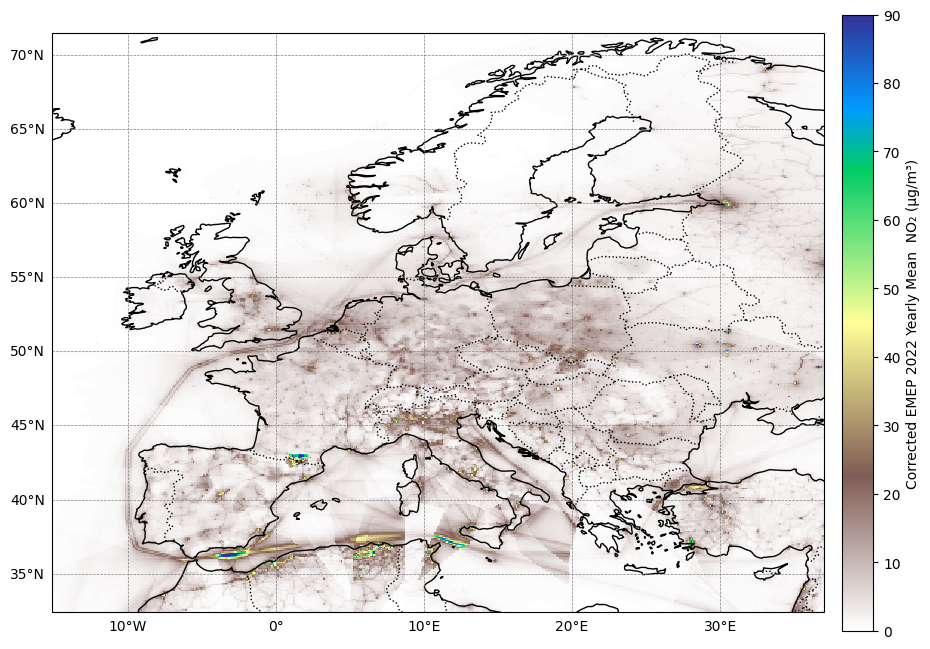

In [22]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# === Load the Corrected Scenario NO₂ NetCDF File ===
corrected_netcdf_path = "Scen_2022_UoA_NO2_SCA.Cell.Mult.IDW_CORR_YEARLY.nc"  # Adjust path if needed
ds_corrected = xr.open_dataset(corrected_netcdf_path)

# Extract corrected NO₂ scenario values
corrected_no2 = ds_corrected["SURF_ug_NO2"].squeeze().values.T

# Extract coordinates
lon = ds_corrected["lon"].values
lat = ds_corrected["lat"].values

# Create a 2D meshgrid for lon & lat
Lon, Lat = np.meshgrid(lon, lat)

# === Define Color Normalization Scale for NO₂ ===
norm = mcolors.Normalize(0, 90)  # Adjust scale for NO₂ concentration range (µg/m³)

# Create a figure with a map projection
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the corrected NO₂ scenario using pcolormesh
mesh = ax.pcolormesh(Lon, Lat, corrected_no2, cmap='terrain_r', shading='auto', transform=ccrs.PlateCarree(), norm=norm)

# Add a colorbar
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label("Corrected EMEP 2022 Yearly Mean  NO₂ (µg/m³)")

# Add coastlines and borders for context
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Add gridlines and labels for longitude and latitude
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False  # Remove top labels
gl.right_labels = False  # Remove right-side labels

# Set title and labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

# Close dataset
ds_corrected.close()

In [23]:
import netCDF4 as nc
import numpy as np

# === Define File Paths ===
scenario_perturbed_nc_path = "EMEP_yearly_2023.nc"  # Perturbed Scenario NetCDF
bias_residual_nc_path = "BaseCase_NO2_Y_IDW_MUL.nc"  # Interpolated Bias Ratios NetCDF
corrected_scenario_nc_path = "Scenario_Corrected3_NO2_MUL.nc"  # Output Corrected Scenario NetCDF

# === Load NetCDF Files ===
with nc.Dataset(scenario_perturbed_nc_path, "r") as scen_nc, \
     nc.Dataset(bias_residual_nc_path, "r") as bias_nc:

    # Load grid and data
    lon = scen_nc.variables["lon"][:]
    lat = scen_nc.variables["lat"][:]
    time = scen_nc.variables["time"][:]

    no2_scenario_perturbed = scen_nc.variables["SURF_ug_NO2"][:]  # Perturbed Scenario NO₂
    interpolated_bias_ratios = bias_nc.variables["Interpolated_Bias"][:]  # Interpolated Bias Ratios (OBS / MOD)

    # === Apply Multiplicative Correction ===
    min_ratio_threshold = 0.1  # Optional: prevent extreme downscaling
    interpolated_bias_ratios = np.maximum(interpolated_bias_ratios, min_ratio_threshold)

    no2_scenario_corrected = no2_scenario_perturbed * interpolated_bias_ratios

    # === Save Corrected Scenario ===
    with nc.Dataset(corrected_scenario_nc_path, "w", format="NETCDF4") as new_nc:

        # Create dimensions
        new_nc.createDimension("time", None)
        new_nc.createDimension("lat", lat.shape[0])
        new_nc.createDimension("lon", lon.shape[0])

        # Create variables
        time_var = new_nc.createVariable("time", "f4", ("time",))
        lat_var = new_nc.createVariable("lat", "f4", ("lat",))
        lon_var = new_nc.createVariable("lon", "f4", ("lon",))
        no2_var = new_nc.createVariable("SURF_ug_NO2_corrected", "f4", ("time", "lat", "lon"), fill_value=-9999.0)

        # Copy attributes from the scenario
        no2_var.setncatts(scen_nc.variables["SURF_ug_NO2"].__dict__)

        # Write data
        time_var[:] = time
        lat_var[:] = lat
        lon_var[:] = lon
        no2_var[:] = no2_scenario_corrected

print("Multiplicative IDW Bias Correction Applied Successfully!")

Multiplicative IDW Bias Correction Applied Successfully!


In [24]:
import netCDF4 as nc
import numpy as np
import shutil

# === Define File Paths ===
input_file = "Scenario_Corrected3_NO2_MUL.nc"  # Your original file
output_file = "Scen_2023_UoA_NO2_SCA.Cell.Mult.IDW_CORR_YEARLY.nc"  # Renamed final file
jrc_reference_file = "EMEP_yearly_2023.nc"  # JRC reference file

# === Backup Original File Before Modifying ===
shutil.copy(input_file, output_file)

# === Open Original NetCDF and Read Data ===
with nc.Dataset(input_file, "r") as src:

    # Read dimensions
    lon = src.variables["lon"][:]
    lat = src.variables["lat"][:]
    time = src.variables["time"][:]
    o3_data = src.variables["SURF_ug_NO2_corrected"][:]  # Read O3 data

    # Open new NetCDF file for writing with correct dimension order
    with nc.Dataset(output_file, "w", format="NETCDF4") as dst:

        # === Create Dimensions in Correct Order ===
        dst.createDimension("lon", len(lon))
        dst.createDimension("lat", len(lat))
        dst.createDimension("time", None)  # Keep time as unlimited

        # === Create Variables in Correct Order ===
        lon_var = dst.createVariable("lon", "f4", ("lon",))
        lat_var = dst.createVariable("lat", "f4", ("lat",))
        time_var = dst.createVariable("time", "f4", ("time",))
        o3_var = dst.createVariable("SURF_ug_NO2", "f4", ("lon", "lat", "time"), fill_value=-9999.0)

        # === Copy Attributes from Original File ===
        for attr in src.ncattrs():
            dst.setncattr(attr, src.getncattr(attr))

        # === Add Missing Global Attributes ===
        jrc_attributes = {
            "vert_coord": "atmosphere_hybrid_sigma_pressure_coordinate",
            "Conventions": "CF-1.6 for coordinates",
            "model": "EMEP_MSC-W",
            "author_of_run": "UoA",
            "created_date": "20250315",
            "created_hour": "091845.466",
            "lastmodified_date": "20241122",
            "lastmodified_hour": "084815.947",
            "projection": "lon lat",
            "period_type": "fullrun",
            "run_label": "Opensource_Setup_2025",
            "history": "Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_NO2",
            "NCO": "netCDF Operators version 5.0.6 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco)"
        }
        for attr, value in jrc_attributes.items():
            dst.setncattr(attr, value)

        # === Copy Variable Data (Reordered) ===
        lon_var[:] = lon
        lat_var[:] = lat
        time_var[:] = time
        o3_var[:, :, :] = np.transpose(o3_data, (2, 1, 0))  # Reorder from (time, lat, lon) to (lon, lat, time)

print(f" Correction completed! Renamed and fixed NetCDF saved as: {output_file}")

# === Function to Extract NetCDF Structure ===
def get_netcdf_structure(filepath):
    with nc.Dataset(filepath, "r") as dataset:
        structure = {
            "dimensions": {dim: dataset.dimensions[dim].size for dim in dataset.dimensions},
            "variables": {var: dataset.variables[var].dimensions for var in dataset.variables},
            "attributes": {attr: dataset.getncattr(attr) for attr in dataset.ncattrs()}
        }
    return structure

# Extract structures
your_structure = get_netcdf_structure(output_file)
jrc_structure = get_netcdf_structure(jrc_reference_file)

# === Compare Structures ===
print("\n=== DIMENSIONS COMPARISON ===")
print("Your File:", your_structure["dimensions"])
print("JRC File:", jrc_structure["dimensions"])

print("\n=== VARIABLES COMPARISON ===")
print("Your File:", list(your_structure["variables"].keys()))
print("JRC File:", list(jrc_structure["variables"].keys()))

print("\n=== GLOBAL ATTRIBUTES COMPARISON ===")
print("Your File:", your_structure["attributes"])
print("JRC File:", jrc_structure["attributes"])

 Correction completed! Renamed and fixed NetCDF saved as: Scen_2023_UoA_NO2_SCA.Cell.Mult.IDW_CORR_YEARLY.nc

=== DIMENSIONS COMPARISON ===
Your File: {'lon': 521, 'lat': 391, 'time': 1}
JRC File: {'time': 1, 'lat': 391, 'lon': 521}

=== VARIABLES COMPARISON ===
Your File: ['lon', 'lat', 'time', 'SURF_ug_NO2']
JRC File: ['time', 'lat', 'lon', 'SURF_ug_PM25_rh50', 'SURF_ug_NO2', 'SURF_ug_O3']

=== GLOBAL ATTRIBUTES COMPARISON ===
Your File: {'vert_coord': 'atmosphere_hybrid_sigma_pressure_coordinate', 'Conventions': 'CF-1.6 for coordinates', 'model': 'EMEP_MSC-W', 'author_of_run': 'UoA', 'created_date': '20250315', 'created_hour': '091845.466', 'lastmodified_date': '20241122', 'lastmodified_hour': '084815.947', 'projection': 'lon lat', 'period_type': 'fullrun', 'run_label': 'Opensource_Setup_2025', 'history': 'Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_NO2', 'NCO': 'netCDF Operators version 5.0.6 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco)'}
JRC File: {'vert

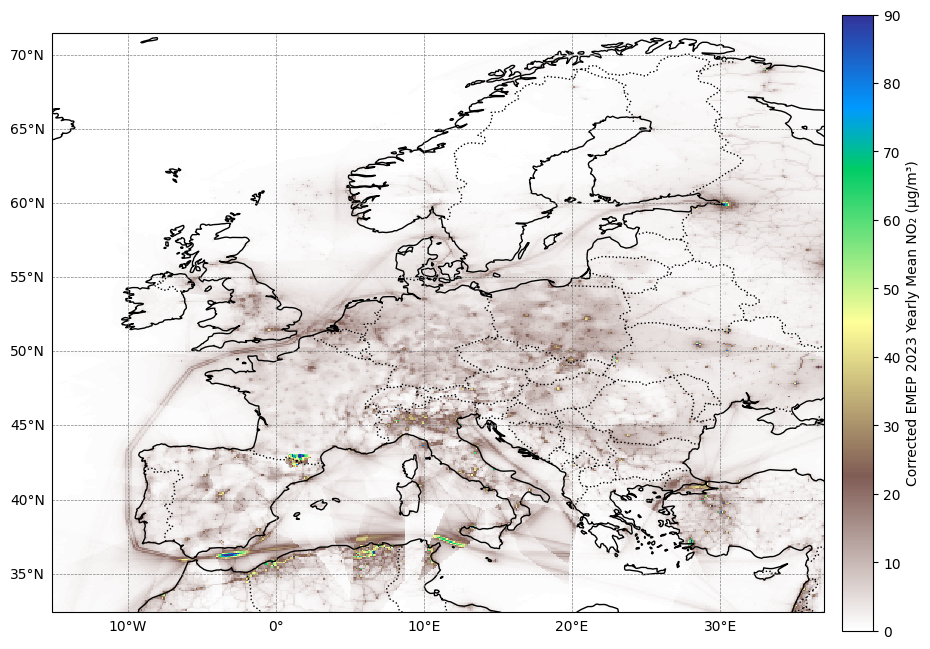

In [25]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# === Load the Corrected Scenario NO₂ NetCDF File ===
corrected_netcdf_path = "Scen_2023_UoA_NO2_SCA.Cell.Mult.IDW_CORR_YEARLY.nc"  # Adjust path if needed
ds_corrected = xr.open_dataset(corrected_netcdf_path)

# Extract corrected NO₂ scenario values
corrected_no2 = ds_corrected["SURF_ug_NO2"].squeeze().values.T

# Extract coordinates
lon = ds_corrected["lon"].values
lat = ds_corrected["lat"].values

# Create a 2D meshgrid for lon & lat
Lon, Lat = np.meshgrid(lon, lat)

# === Define Color Normalization Scale for NO₂ ===
norm = mcolors.Normalize(0, 90)  # Adjust scale for NO₂ concentration range (µg/m³)

# Create a figure with a map projection
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the corrected NO₂ scenario using pcolormesh
mesh = ax.pcolormesh(Lon, Lat, corrected_no2, cmap='terrain_r', shading='auto', transform=ccrs.PlateCarree(), norm=norm)

# Add a colorbar
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label("Corrected EMEP 2023 Yearly Mean NO₂ (µg/m³)")

# Add coastlines and borders for context
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Add gridlines and labels for longitude and latitude
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False  # Remove top labels
gl.right_labels = False  # Remove right-side labels

# Set title and labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

# Close dataset
ds_corrected.close()

In [26]:
import netCDF4 as nc
import numpy as np

# === Define File Paths ===
scenario_perturbed_nc_path = "EMEP_yearly_2024.nc"  # Perturbed Scenario NetCDF
bias_residual_nc_path = "BaseCase_NO2_Y_IDW_MUL.nc"  # Interpolated Bias Ratios NetCDF
corrected_scenario_nc_path = "Scenario_Corrected4_NO2_MUL.nc"  # Output Corrected Scenario NetCDF

# === Load NetCDF Files ===
with nc.Dataset(scenario_perturbed_nc_path, "r") as scen_nc, \
     nc.Dataset(bias_residual_nc_path, "r") as bias_nc:

    # Load grid and data
    lon = scen_nc.variables["lon"][:]
    lat = scen_nc.variables["lat"][:]
    time = scen_nc.variables["time"][:]

    no2_scenario_perturbed = scen_nc.variables["SURF_ug_NO2"][:]  # Perturbed Scenario NO₂
    interpolated_bias_ratios = bias_nc.variables["Interpolated_Bias"][:]  # Interpolated Bias Ratios (OBS / MOD)

    # === Apply Multiplicative Correction ===
    min_ratio_threshold = 0.1  # Optional: prevent extreme downscaling
    interpolated_bias_ratios = np.maximum(interpolated_bias_ratios, min_ratio_threshold)

    no2_scenario_corrected = no2_scenario_perturbed * interpolated_bias_ratios

    # === Save Corrected Scenario ===
    with nc.Dataset(corrected_scenario_nc_path, "w", format="NETCDF4") as new_nc:

        # Create dimensions
        new_nc.createDimension("time", None)
        new_nc.createDimension("lat", lat.shape[0])
        new_nc.createDimension("lon", lon.shape[0])

        # Create variables
        time_var = new_nc.createVariable("time", "f4", ("time",))
        lat_var = new_nc.createVariable("lat", "f4", ("lat",))
        lon_var = new_nc.createVariable("lon", "f4", ("lon",))
        no2_var = new_nc.createVariable("SURF_ug_NO2_corrected", "f4", ("time", "lat", "lon"), fill_value=-9999.0)

        # Copy attributes from the scenario
        no2_var.setncatts(scen_nc.variables["SURF_ug_NO2"].__dict__)

        # Write data
        time_var[:] = time
        lat_var[:] = lat
        lon_var[:] = lon
        no2_var[:] = no2_scenario_corrected

print("Multiplicative IDW Bias Correction Applied Successfully!")

Multiplicative IDW Bias Correction Applied Successfully!


In [27]:
import netCDF4 as nc
import numpy as np
import shutil

# === Define File Paths ===
input_file = "Scenario_Corrected4_NO2_MUL.nc"  # Your original file
output_file = "Scen_2024_UoA_NO2_SCA.Cell.Mult.IDW_CORR_YEARLY.nc"  # Renamed final file
jrc_reference_file = "EMEP_yearly_2024.nc"  # JRC reference file

# === Backup Original File Before Modifying ===
shutil.copy(input_file, output_file)

# === Open Original NetCDF and Read Data ===
with nc.Dataset(input_file, "r") as src:

    # Read dimensions
    lon = src.variables["lon"][:]
    lat = src.variables["lat"][:]
    time = src.variables["time"][:]
    o3_data = src.variables["SURF_ug_NO2_corrected"][:]  # Read O3 data

    # Open new NetCDF file for writing with correct dimension order
    with nc.Dataset(output_file, "w", format="NETCDF4") as dst:

        # === Create Dimensions in Correct Order ===
        dst.createDimension("lon", len(lon))
        dst.createDimension("lat", len(lat))
        dst.createDimension("time", None)  # Keep time as unlimited

        # === Create Variables in Correct Order ===
        lon_var = dst.createVariable("lon", "f4", ("lon",))
        lat_var = dst.createVariable("lat", "f4", ("lat",))
        time_var = dst.createVariable("time", "f4", ("time",))
        o3_var = dst.createVariable("SURF_ug_NO2", "f4", ("lon", "lat", "time"), fill_value=-9999.0)

        # === Copy Attributes from Original File ===
        for attr in src.ncattrs():
            dst.setncattr(attr, src.getncattr(attr))

        # === Add Missing Global Attributes ===
        jrc_attributes = {
            "vert_coord": "atmosphere_hybrid_sigma_pressure_coordinate",
            "Conventions": "CF-1.6 for coordinates",
            "model": "EMEP_MSC-W",
            "author_of_run": "UoA",
            "created_date": "20250315",
            "created_hour": "091845.466",
            "lastmodified_date": "20241122",
            "lastmodified_hour": "084815.947",
            "projection": "lon lat",
            "period_type": "fullrun",
            "run_label": "Opensource_Setup_2025",
            "history": "Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_NO2",
            "NCO": "netCDF Operators version 5.0.6 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco)"
        }
        for attr, value in jrc_attributes.items():
            dst.setncattr(attr, value)

        # === Copy Variable Data (Reordered) ===
        lon_var[:] = lon
        lat_var[:] = lat
        time_var[:] = time
        o3_var[:, :, :] = np.transpose(o3_data, (2, 1, 0))  # Reorder from (time, lat, lon) to (lon, lat, time)

print(f" Correction completed! Renamed and fixed NetCDF saved as: {output_file}")

# === Function to Extract NetCDF Structure ===
def get_netcdf_structure(filepath):
    with nc.Dataset(filepath, "r") as dataset:
        structure = {
            "dimensions": {dim: dataset.dimensions[dim].size for dim in dataset.dimensions},
            "variables": {var: dataset.variables[var].dimensions for var in dataset.variables},
            "attributes": {attr: dataset.getncattr(attr) for attr in dataset.ncattrs()}
        }
    return structure

# Extract structures
your_structure = get_netcdf_structure(output_file)
jrc_structure = get_netcdf_structure(jrc_reference_file)

# === Compare Structures ===
print("\n=== DIMENSIONS COMPARISON ===")
print("Your File:", your_structure["dimensions"])
print("JRC File:", jrc_structure["dimensions"])

print("\n=== VARIABLES COMPARISON ===")
print("Your File:", list(your_structure["variables"].keys()))
print("JRC File:", list(jrc_structure["variables"].keys()))

print("\n=== GLOBAL ATTRIBUTES COMPARISON ===")
print("Your File:", your_structure["attributes"])
print("JRC File:", jrc_structure["attributes"])

 Correction completed! Renamed and fixed NetCDF saved as: Scen_2024_UoA_NO2_SCA.Cell.Mult.IDW_CORR_YEARLY.nc

=== DIMENSIONS COMPARISON ===
Your File: {'lon': 521, 'lat': 391, 'time': 1}
JRC File: {'time': 1, 'lat': 391, 'lon': 521}

=== VARIABLES COMPARISON ===
Your File: ['lon', 'lat', 'time', 'SURF_ug_NO2']
JRC File: ['time', 'lat', 'lon', 'SURF_ug_PM25_rh50', 'SURF_ug_NO2', 'SURF_ug_O3']

=== GLOBAL ATTRIBUTES COMPARISON ===
Your File: {'vert_coord': 'atmosphere_hybrid_sigma_pressure_coordinate', 'Conventions': 'CF-1.6 for coordinates', 'model': 'EMEP_MSC-W', 'author_of_run': 'UoA', 'created_date': '20250315', 'created_hour': '091845.466', 'lastmodified_date': '20241122', 'lastmodified_hour': '084815.947', 'projection': 'lon lat', 'period_type': 'fullrun', 'run_label': 'Opensource_Setup_2025', 'history': 'Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_NO2', 'NCO': 'netCDF Operators version 5.0.6 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco)'}
JRC File: {'vert

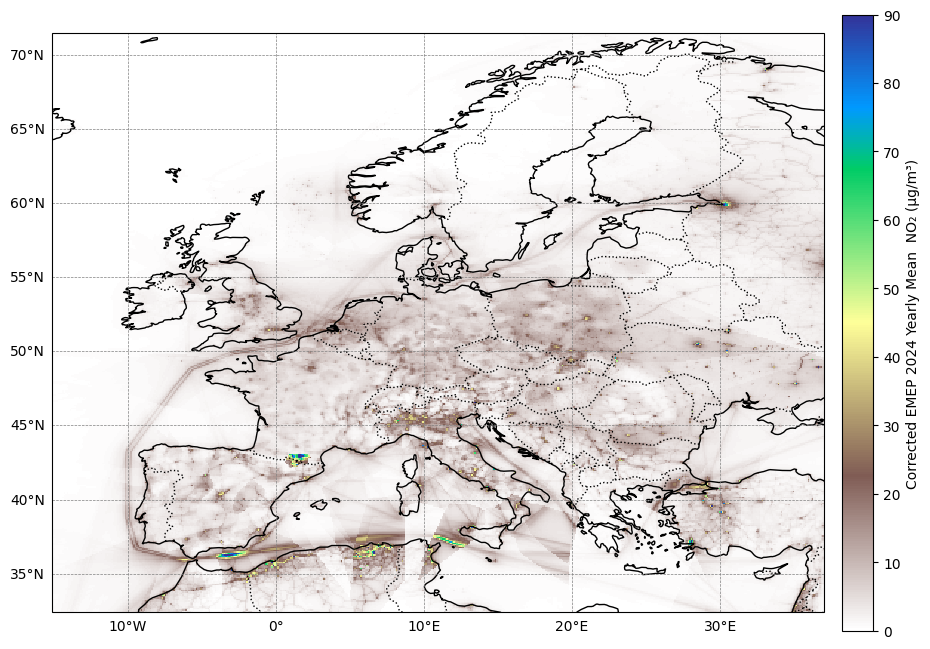

In [28]:

import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# === Load the Corrected Scenario NO₂ NetCDF File ===
corrected_netcdf_path = "Scen_2024_UoA_NO2_SCA.Cell.Mult.IDW_CORR_YEARLY.nc"  # Adjust path if needed
ds_corrected = xr.open_dataset(corrected_netcdf_path)

# Extract corrected NO₂ scenario values
corrected_no2 = ds_corrected["SURF_ug_NO2"].squeeze().values.T

# Extract coordinates
lon = ds_corrected["lon"].values
lat = ds_corrected["lat"].values

# Create a 2D meshgrid for lon & lat
Lon, Lat = np.meshgrid(lon, lat)

# === Define Color Normalization Scale for NO₂ ===
norm = mcolors.Normalize(0, 90)  # Adjust scale for NO₂ concentration range (µg/m³)

# Create a figure with a map projection
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the corrected NO₂ scenario using pcolormesh
mesh = ax.pcolormesh(Lon, Lat, corrected_no2, cmap='terrain_r', shading='auto', transform=ccrs.PlateCarree(), norm=norm)

# Add a colorbar
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label("Corrected EMEP 2024 Yearly Mean  NO₂ (µg/m³)")

# Add coastlines and borders for context
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Add gridlines and labels for longitude and latitude
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False  # Remove top labels
gl.right_labels = False  # Remove right-side labels

# Set title and labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

# Close dataset
ds_corrected.close()


In [35]:
import numpy as np
import os

input_dir = "/content/NO2"
output_dir = "/content/Results_NO2"

variables_to_fix = [
    "SURF_ug_NO2",
    "SURF_ug_O3",              # corrected name
    "SURF_ug_PM25_rh50"
]

correct_dims = ("time", "lat", "lon")

os.makedirs(output_dir, exist_ok=True)

for file in os.listdir(input_dir):
    if file.endswith(".nc"):

        input_path = os.path.join(input_dir, file)
        output_path = os.path.join(output_dir, file)

        print(f"\nProcessing: {file}")

        with nc.Dataset(input_path, "r") as src:
            lon = src.variables["lon"][:]
            lat = src.variables["lat"][:]
            time = src.variables["time"][:]

            global_attrs = {attr: src.getncattr(attr) for attr in src.ncattrs()}

            with nc.Dataset(output_path, "w", format="NETCDF4") as dst:

                # === FIXED DIMENSIONS ===
                dst.createDimension("lon", len(lon))
                dst.createDimension("lat", len(lat))
                dst.createDimension("time", len(time))   # NOT unlimited

                # === COORDINATES (correct dtype) ===
                lon_var = dst.createVariable("lon", "f8", ("lon",))
                lat_var = dst.createVariable("lat", "f8", ("lat",))
                time_var = dst.createVariable("time", "f8", ("time",))

                lon_var[:] = lon
                lat_var[:] = lat
                time_var[:] = time

                # Copy coordinate attributes
                for coord in ["lon", "lat", "time"]:
                    for attr in src.variables[coord].ncattrs():
                        getattr(dst.variables[coord], "setncattr")(
                            attr, src.variables[coord].getncattr(attr)
                        )

                # === Global attributes ===
                for attr, value in global_attrs.items():
                    dst.setncattr(attr, value)

                # === Variables ===
                for var_name in variables_to_fix:

                    if var_name not in src.variables:
                        print(f"  ⚠ {var_name} not found.")
                        continue

                    var = src.variables[var_name]
                    dims = var.dimensions
                    data = var[:]
                    var_attrs = {a: var.getncattr(a) for a in var.ncattrs()}

                    # === Reshape if needed ===
                    if dims != correct_dims:

                        print(f"   Reshaping {var_name}: {dims} → {correct_dims}")

                        if dims == ("lon", "lat", "time"):
                            data = np.transpose(data, (2, 1, 0))
                        elif dims == ("lat", "lon", "time"):
                            data = np.transpose(data, (2, 0, 1))
                        else:
                            print(f"   ⚠ Unknown dimension order {dims}")
                            continue

                    # === Write variable ===
                    fill_value = var_attrs.pop("_FillValue", -9999.0)

                    var_out = dst.createVariable(
                        var_name,
                        "f4",
                        correct_dims,
                        fill_value=fill_value
                    )

                    for attr, value in var_attrs.items():
                        var_out.setncattr(attr, value)

                    var_out[:] = data

        print(f"  ✔ Saved to {output_path}")

print("\n✔ All files processed correctly.")


Processing: Scen_2024_UoA_NO2_SCA.Cell.Mult.IDW_CORR_YEARLY.nc
   Reshaping SURF_ug_NO2: ('lon', 'lat', 'time') → ('time', 'lat', 'lon')
  ⚠ SURF_ug_O3 not found.
  ⚠ SURF_ug_PM25_rh50 not found.
  ✔ Saved to /content/Results_NO2/Scen_2024_UoA_NO2_SCA.Cell.Mult.IDW_CORR_YEARLY.nc

Processing: Scen_2023_UoA_NO2_SCA.Cell.Mult.IDW_CORR_YEARLY.nc
   Reshaping SURF_ug_NO2: ('lon', 'lat', 'time') → ('time', 'lat', 'lon')
  ⚠ SURF_ug_O3 not found.
  ⚠ SURF_ug_PM25_rh50 not found.
  ✔ Saved to /content/Results_NO2/Scen_2023_UoA_NO2_SCA.Cell.Mult.IDW_CORR_YEARLY.nc

Processing: Scen_2022_UoA_NO2_SCA.Cell.Mult.IDW_CORR_YEARLY.nc
   Reshaping SURF_ug_NO2: ('lon', 'lat', 'time') → ('time', 'lat', 'lon')
  ⚠ SURF_ug_O3 not found.
  ⚠ SURF_ug_PM25_rh50 not found.
  ✔ Saved to /content/Results_NO2/Scen_2022_UoA_NO2_SCA.Cell.Mult.IDW_CORR_YEARLY.nc

Processing: BaseCase_UoA_NO2_SCA.Cell.Mult.IDW_CORR_YEARLY.nc
   Reshaping SURF_ug_NO2: ('lon', 'lat', 'time') → ('time', 'lat', 'lon')
  ⚠ SURF_ug_O3 no

Shapes: (391, 521) (391, 521)

===== GLOBAL PERFORMANCE =====

RAW
RMSE: 9.75942406856348
MAE: 7.55685349179529
Bias: -6.317512854057136
R: 0.6809700825471148
R² (corr): 0.4637202533242243
R² (true): -0.01650385720215719

ADI
RMSE: 3.606847253272114
MAE: 2.1066495027494003
Bias: -0.7307065822703113
R: 0.9310525101863841
R² (corr): 0.866858776724367
R² (true): 0.8611595049694849

===== COUNTRY METRICS =====
   Country   RMSE_Raw   RMSE_WDI   Bias_Raw  Bias_WDI    R2_Raw    R2_WDI    N
5       CY   0.375192   0.021764  -0.375192  0.021764       NaN       NaN    1
11      FI   0.565070   0.032189  -0.562822  0.025440  1.000000  1.000000    2
30      SI   0.378095   0.058294   0.378095  0.058294       NaN       NaN    1
17      IE   3.154469   0.668460   1.809215 -0.546251  0.830282  0.997326    6
29      SE   3.077791   0.982370  -0.228036 -0.303188  0.767031  0.981065   33
9       EE   2.937448   1.046440  -2.011185 -0.581054  0.902211  0.987076    5
8       DK   2.394992   1.145256  -1.

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


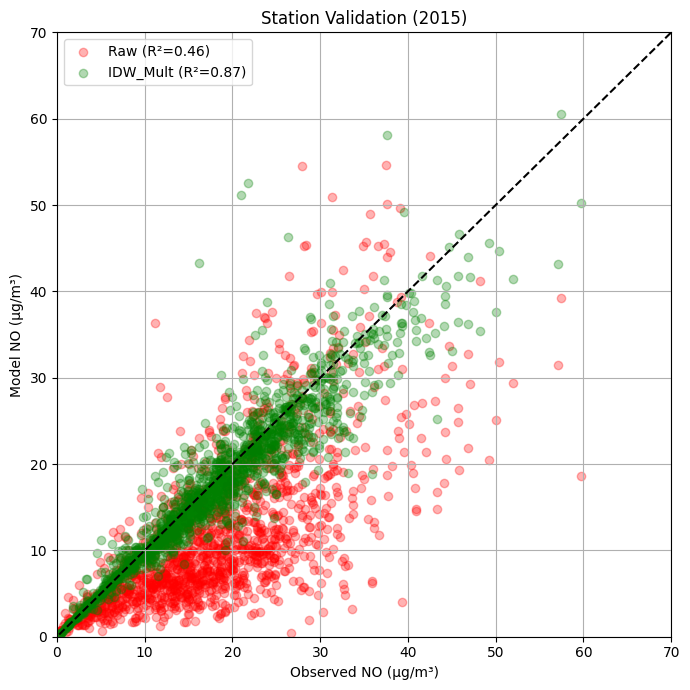

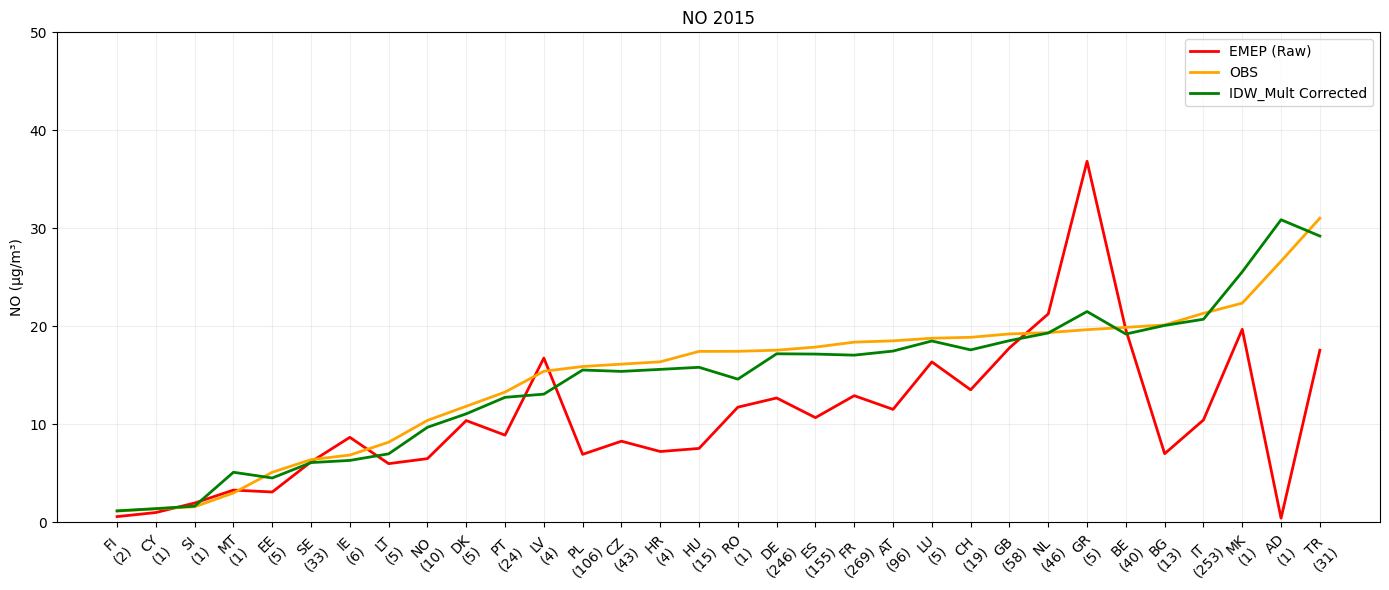

Shapes: (391, 521) (391, 521)

===== GLOBAL PERFORMANCE =====

RAW
RMSE: 7.865063029200579
MAE: 5.874355408493154
Bias: -4.317399503993686
R: 0.603294093424608
R² (corr): 0.3639637631610197
R² (true): -0.20860050524221063

ADI
RMSE: 5.037325484875948
MAE: 2.9966988159170898
Bias: 0.38832074610669326
R: 0.7974368258354749
R² (corr): 0.6359054911985575
R² (true): 0.50423212254325

===== COUNTRY METRICS =====
   Country   RMSE_Raw   RMSE_WDI   Bias_Raw  Bias_WDI    R2_Raw    R2_WDI    N
11      FI   0.416427   0.090895  -0.415480  0.082974  1.000000  1.000000    2
20      LV   0.646814   0.321289  -0.646814 -0.321289       NaN       NaN    1
22      NO   3.794561   0.508539  -1.755501  0.144687  0.588497  0.992926    4
9       EE   2.396287   1.090132  -1.475336 -0.232425  0.964776  0.924778    5
5       CY   2.041407   1.653914  -2.041407 -1.653914       NaN       NaN    1
18      LT   3.820113   1.666562  -1.983651 -1.076954  0.504451  0.998071    4
25      SE   2.698061   1.713951   0.

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


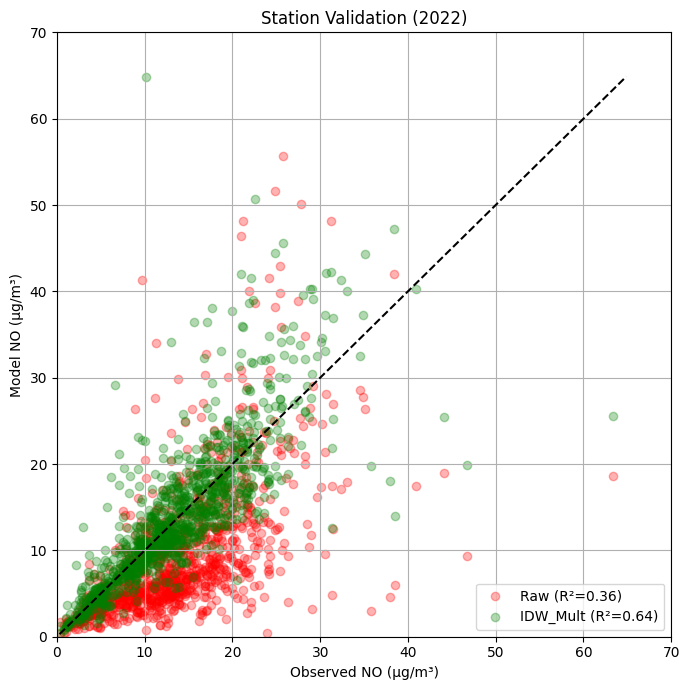

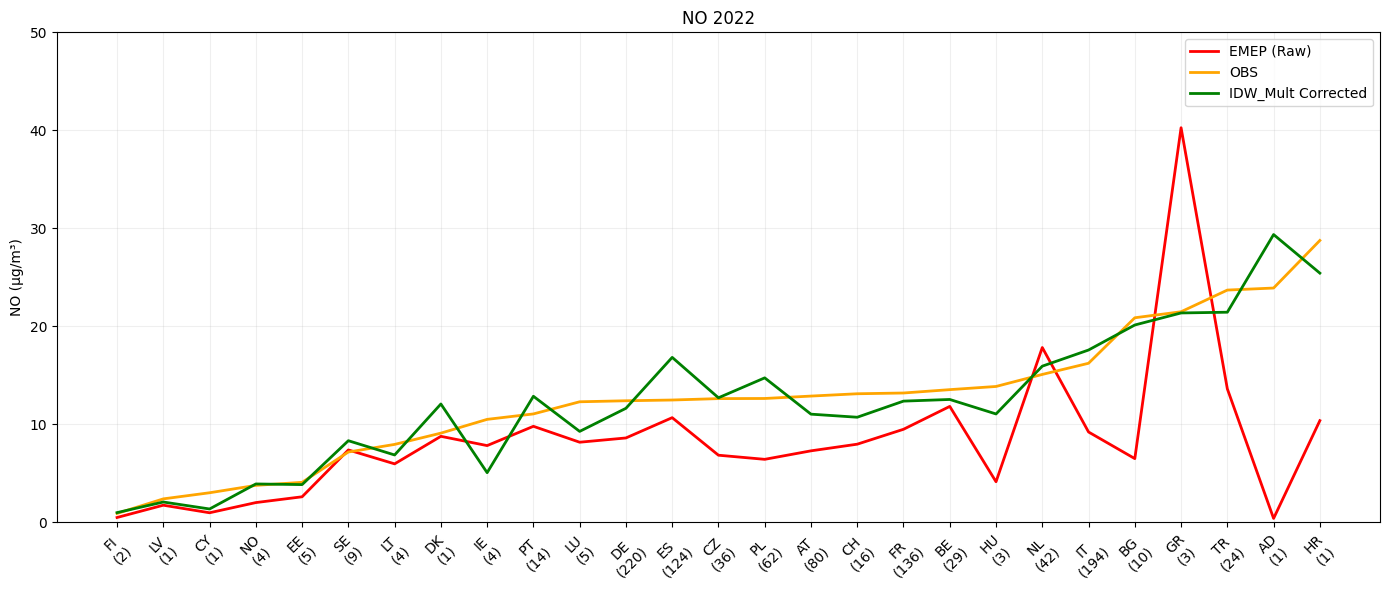

In [39]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ======================================================
# 1. LOAD MODELS
# ======================================================
ds_raw = xr.open_dataset("EMEP_yearly_2022.nc")
ds_wdi = xr.open_dataset("Scen_2022_NKUA_NO2_CSA.Cell.Mult.IDW_CORR_YEARLY.nc")

lon = ds_raw["lon"].values
lat = ds_raw["lat"].values

raw = ds_raw["SURF_ug_NO2"].values
wdi = ds_wdi["SURF_ug_NO2"].values

# handle time dimension
if raw.ndim == 3:
    raw = raw[0]
if wdi.ndim == 3:
    wdi = wdi[0]

ds_raw.close()
ds_wdi.close()

print("Shapes:", raw.shape, wdi.shape)

# ======================================================
# 2. LOAD STATIONS
# ======================================================
df = pd.read_csv("yearly_NO2_2022.csv")

if df["Longitude"].max() > 180:
    df["Longitude"] = ((df["Longitude"] + 180) % 360) - 180

df["Country"] = df["Station"].str[:2]

# ======================================================
# 3. BILINEAR INTERPOLATION
# ======================================================
def bilinear_interp(lon_pt, lat_pt, lon, lat, field):

    i = np.searchsorted(lon, lon_pt) - 1
    j = np.searchsorted(lat, lat_pt) - 1

    i = np.clip(i, 0, len(lon) - 2)
    j = np.clip(j, 0, len(lat) - 2)

    x1, x2 = lon[i], lon[i+1]
    y1, y2 = lat[j], lat[j+1]

    Q11 = field[j, i]
    Q21 = field[j, i+1]
    Q12 = field[j+1, i]
    Q22 = field[j+1, i+1]

    return (
        Q11 * (x2 - lon_pt) * (y2 - lat_pt) +
        Q21 * (lon_pt - x1) * (y2 - lat_pt) +
        Q12 * (x2 - lon_pt) * (lat_pt - y1) +
        Q22 * (lon_pt - x1) * (lat_pt - y1)
    ) / ((x2 - x1) * (y2 - y1))

# ======================================================
# 4. EXTRACT MODEL VALUES
# ======================================================
raw_vals = []
wdi_vals = []

for _, row in df.iterrows():
    lo = row["Longitude"]
    la = row["Latitude"]

    raw_vals.append(bilinear_interp(lo, la, lon, lat, raw))
    wdi_vals.append(bilinear_interp(lo, la, lon, lat, wdi))

df["Model_Raw"] = raw_vals
df["Model_WDI"] = wdi_vals

# ======================================================
# 5. CLEAN
# ======================================================
df = df.dropna(subset=["Average", "Model_Raw", "Model_WDI"])

obs = df["Average"].values
raw_vals = df["Model_Raw"].values
wdi_vals = df["Model_WDI"].values

# ======================================================
# 6. METRICS
# ======================================================
def rmse(a, b):
    return np.sqrt(np.mean((a - b)**2))

def mae(a, b):
    return np.mean(np.abs(a - b))

def bias(a, b):
    return np.mean(a - b)

def corr(a, b):
    return np.corrcoef(a, b)[0,1]

def r2_from_corr(r):
    return r**2

def r2_true(model, obs):
    ss_res = np.sum((obs - model)**2)
    ss_tot = np.sum((obs - np.mean(obs))**2)
    return 1 - ss_res / ss_tot

print("\n===== GLOBAL PERFORMANCE =====")

# compute once
r_raw = corr(raw_vals, obs)
r_wdi = corr(wdi_vals, obs)

r2_raw_corr = r2_from_corr(r_raw)
r2_wdi_corr = r2_from_corr(r_wdi)

r2_raw_true = r2_true(raw_vals, obs)
r2_wdi_true = r2_true(wdi_vals, obs)

print("\nRAW")
print("RMSE:", rmse(raw_vals, obs))
print("MAE:", mae(raw_vals, obs))
print("Bias:", bias(raw_vals, obs))
print("R:", r_raw)
print("R² (corr):", r2_raw_corr)
print("R² (true):", r2_raw_true)

print("\nADI")
print("RMSE:", rmse(wdi_vals, obs))
print("MAE:", mae(wdi_vals, obs))
print("Bias:", bias(wdi_vals, obs))
print("R:", r_wdi)
print("R² (corr):", r2_wdi_corr)
print("R² (true):", r2_wdi_true)

# ======================================================
# 7. COUNTRY METRICS
# ======================================================
results = []

for country, group in df.groupby("Country"):

    obs_c = group["Average"].values
    raw_c = group["Model_Raw"].values
    wdi_c = group["Model_WDI"].values

    r_raw_c = corr(raw_c, obs_c)
    r_wdi_c = corr(wdi_c, obs_c)

    results.append({
        "Country": country,
        "RMSE_Raw": rmse(raw_c, obs_c),
        "RMSE_WDI": rmse(wdi_c, obs_c),
        "Bias_Raw": bias(raw_c, obs_c),
        "Bias_WDI": bias(wdi_c, obs_c),
        "R2_Raw": r_raw_c**2,
        "R2_WDI": r_wdi_c**2,
        "N": len(group)
    })

metrics_df = pd.DataFrame(results).sort_values("RMSE_WDI")

print("\n===== COUNTRY METRICS =====")
print(metrics_df)

# ======================================================
# 8. SCATTER PLOT
# ======================================================
plt.figure(figsize=(7,7))

plt.scatter(obs, raw_vals,
            label=f"Raw (R²={r2_raw_corr:.2f})",
            alpha=0.3, color='red')

plt.scatter(obs, wdi_vals,
            label=f"IDW_Mult (R²={r2_wdi_corr:.2f})",
            alpha=0.3, color='green')

min_v = min(obs.min(), raw_vals.min(), wdi_vals.min())
max_v = max(obs.max(), raw_vals.max(), wdi_vals.max())

plt.plot([min_v, max_v], [min_v, max_v], 'k--')

plt.xlabel("Observed NO (μg/m³)")
plt.ylabel("Model NO (μg/m³)")
plt.title("Station Validation (2022)")
plt.xlim(0,70)
plt.ylim(0,70)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# ======================================================
# 9. COUNTRY PLOT
# ======================================================
country_mean = df.groupby("Country")[[
    "Average",
    "Model_Raw",
    "Model_WDI"
]].mean()

country_mean = country_mean.rename(columns={
    "Average": "OBS",
    "Model_Raw": "RAW",
    "Model_WDI": "WDI"
})

country_mean = country_mean.sort_values("OBS")

nstations = df.groupby("Country").size()
labels = [f"{c}\n({nstations[c]})" for c in country_mean.index]
x = np.arange(len(country_mean))

plt.figure(figsize=(14,6))

plt.plot(x, country_mean["RAW"], color='red', linewidth=2, label="EMEP (Raw)")
plt.plot(x, country_mean["OBS"], color='orange', linewidth=2, label="OBS")
plt.plot(x, country_mean["WDI"], color='green', linewidth=2, label="IDW_Mult Corrected")

plt.xticks(x, labels, rotation=45)
plt.ylabel("NO (μg/m³)")
plt.title("NO 2022")
plt.ylim(0,50)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Shapes: (391, 521) (391, 521)

===== GLOBAL PERFORMANCE =====

RAW
RMSE: 7.4589150470426935
MAE: 5.4577668143433655
Bias: -3.954253850342293
R: 0.5901335028693347
R² (corr): 0.3482575512088311
R² (true): -0.13753706911082575

ADI
RMSE: 5.086282405262622
MAE: 3.077305091791152
Bias: 0.38299518825143575
R: 0.7734567205287058
R² (corr): 0.5982352985310205
R² (true): 0.47104932461144866

===== COUNTRY METRICS =====
   Country   RMSE_Raw   RMSE_WDI   Bias_Raw  Bias_WDI    R2_Raw    R2_WDI    N
20      LV   0.290198   0.015871  -0.290198  0.015871       NaN       NaN    1
11      FI   0.382246   0.121898  -0.380974  0.117497  1.000000  1.000000    2
22      NO   4.333295   0.311496  -1.978614 -0.120431  0.599059  0.998447    4
5       CY   1.209486   0.823196  -1.209486 -0.823196       NaN       NaN    1
9       EE   1.983768   0.880652  -1.274837  0.019925  0.982728  0.905742    5
25      SE   2.745489   1.352450   0.152643  0.998258  0.631309  0.984471    9
14      HR  17.131856   1.564527

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


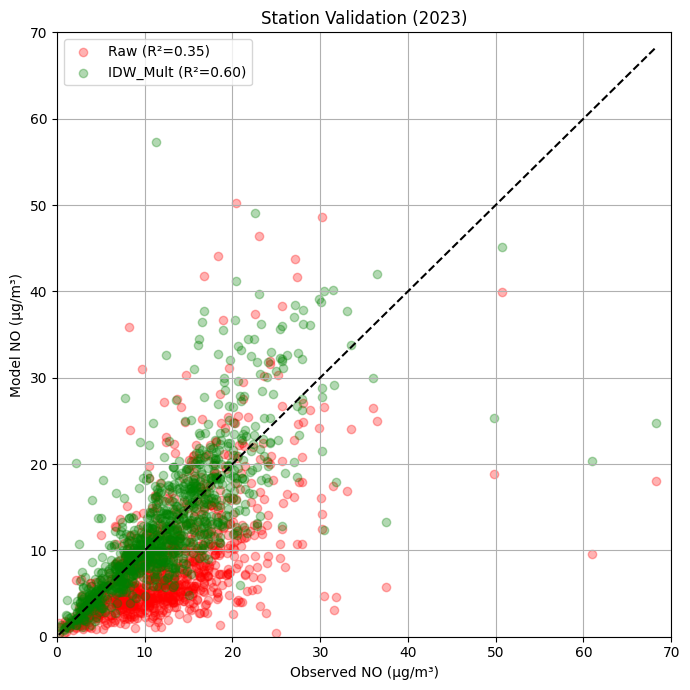

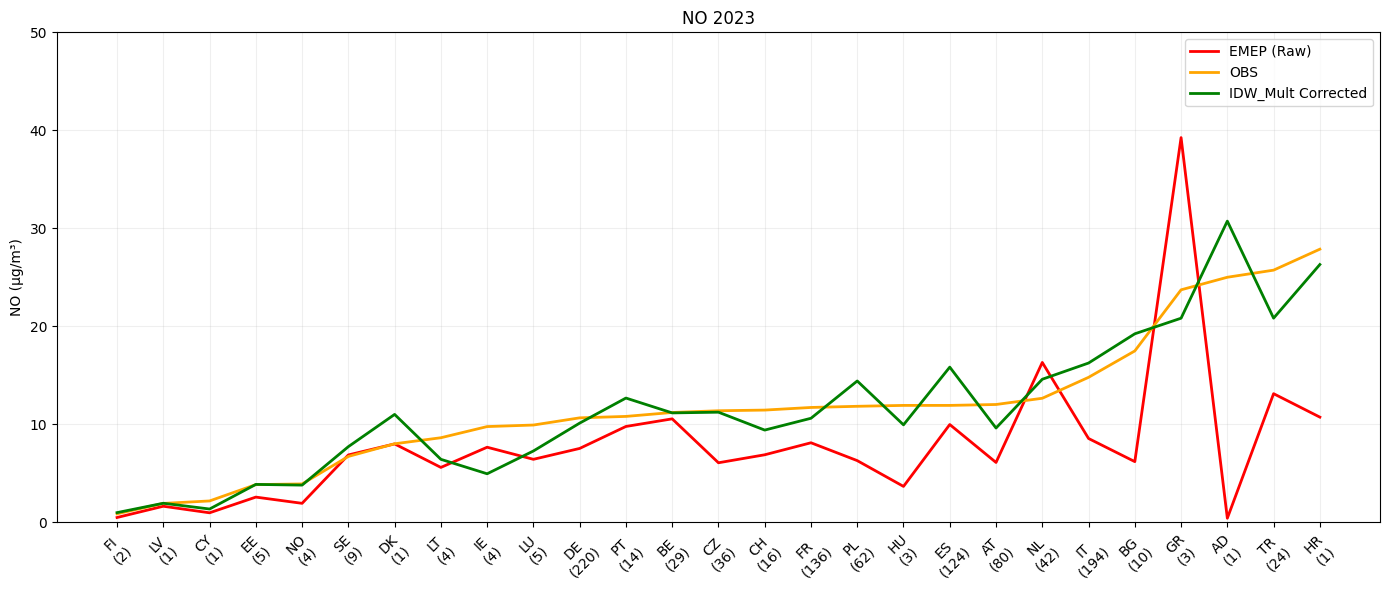

In [40]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ======================================================
# 1. LOAD MODELS
# ======================================================
ds_raw = xr.open_dataset("EMEP_yearly_2023.nc")
ds_wdi = xr.open_dataset("Scen_2023_NKUA_NO2_CSA.Cell.Mult.IDW_CORR_YEARLY.nc")

lon = ds_raw["lon"].values
lat = ds_raw["lat"].values

raw = ds_raw["SURF_ug_NO2"].values
wdi = ds_wdi["SURF_ug_NO2"].values

# handle time dimension
if raw.ndim == 3:
    raw = raw[0]
if wdi.ndim == 3:
    wdi = wdi[0]

ds_raw.close()
ds_wdi.close()

print("Shapes:", raw.shape, wdi.shape)

# ======================================================
# 2. LOAD STATIONS
# ======================================================
df = pd.read_csv("yearly_NO2_2023.csv")

if df["Longitude"].max() > 180:
    df["Longitude"] = ((df["Longitude"] + 180) % 360) - 180

df["Country"] = df["Station"].str[:2]

# ======================================================
# 3. BILINEAR INTERPOLATION
# ======================================================
def bilinear_interp(lon_pt, lat_pt, lon, lat, field):

    i = np.searchsorted(lon, lon_pt) - 1
    j = np.searchsorted(lat, lat_pt) - 1

    i = np.clip(i, 0, len(lon) - 2)
    j = np.clip(j, 0, len(lat) - 2)

    x1, x2 = lon[i], lon[i+1]
    y1, y2 = lat[j], lat[j+1]

    Q11 = field[j, i]
    Q21 = field[j, i+1]
    Q12 = field[j+1, i]
    Q22 = field[j+1, i+1]

    return (
        Q11 * (x2 - lon_pt) * (y2 - lat_pt) +
        Q21 * (lon_pt - x1) * (y2 - lat_pt) +
        Q12 * (x2 - lon_pt) * (lat_pt - y1) +
        Q22 * (lon_pt - x1) * (lat_pt - y1)
    ) / ((x2 - x1) * (y2 - y1))

# ======================================================
# 4. EXTRACT MODEL VALUES
# ======================================================
raw_vals = []
wdi_vals = []

for _, row in df.iterrows():
    lo = row["Longitude"]
    la = row["Latitude"]

    raw_vals.append(bilinear_interp(lo, la, lon, lat, raw))
    wdi_vals.append(bilinear_interp(lo, la, lon, lat, wdi))

df["Model_Raw"] = raw_vals
df["Model_WDI"] = wdi_vals

# ======================================================
# 5. CLEAN
# ======================================================
df = df.dropna(subset=["Average", "Model_Raw", "Model_WDI"])

obs = df["Average"].values
raw_vals = df["Model_Raw"].values
wdi_vals = df["Model_WDI"].values

# ======================================================
# 6. METRICS
# ======================================================
def rmse(a, b):
    return np.sqrt(np.mean((a - b)**2))

def mae(a, b):
    return np.mean(np.abs(a - b))

def bias(a, b):
    return np.mean(a - b)

def corr(a, b):
    return np.corrcoef(a, b)[0,1]

def r2_from_corr(r):
    return r**2

def r2_true(model, obs):
    ss_res = np.sum((obs - model)**2)
    ss_tot = np.sum((obs - np.mean(obs))**2)
    return 1 - ss_res / ss_tot

print("\n===== GLOBAL PERFORMANCE =====")

# compute once
r_raw = corr(raw_vals, obs)
r_wdi = corr(wdi_vals, obs)

r2_raw_corr = r2_from_corr(r_raw)
r2_wdi_corr = r2_from_corr(r_wdi)

r2_raw_true = r2_true(raw_vals, obs)
r2_wdi_true = r2_true(wdi_vals, obs)

print("\nRAW")
print("RMSE:", rmse(raw_vals, obs))
print("MAE:", mae(raw_vals, obs))
print("Bias:", bias(raw_vals, obs))
print("R:", r_raw)
print("R² (corr):", r2_raw_corr)
print("R² (true):", r2_raw_true)

print("\nADI")
print("RMSE:", rmse(wdi_vals, obs))
print("MAE:", mae(wdi_vals, obs))
print("Bias:", bias(wdi_vals, obs))
print("R:", r_wdi)
print("R² (corr):", r2_wdi_corr)
print("R² (true):", r2_wdi_true)

# ======================================================
# 7. COUNTRY METRICS
# ======================================================
results = []

for country, group in df.groupby("Country"):

    obs_c = group["Average"].values
    raw_c = group["Model_Raw"].values
    wdi_c = group["Model_WDI"].values

    r_raw_c = corr(raw_c, obs_c)
    r_wdi_c = corr(wdi_c, obs_c)

    results.append({
        "Country": country,
        "RMSE_Raw": rmse(raw_c, obs_c),
        "RMSE_WDI": rmse(wdi_c, obs_c),
        "Bias_Raw": bias(raw_c, obs_c),
        "Bias_WDI": bias(wdi_c, obs_c),
        "R2_Raw": r_raw_c**2,
        "R2_WDI": r_wdi_c**2,
        "N": len(group)
    })

metrics_df = pd.DataFrame(results).sort_values("RMSE_WDI")

print("\n===== COUNTRY METRICS =====")
print(metrics_df)

# ======================================================
# 8. SCATTER PLOT
# ======================================================
plt.figure(figsize=(7,7))

plt.scatter(obs, raw_vals,
            label=f"Raw (R²={r2_raw_corr:.2f})",
            alpha=0.3, color='red')

plt.scatter(obs, wdi_vals,
            label=f"IDW_Mult (R²={r2_wdi_corr:.2f})",
            alpha=0.3, color='green')

min_v = min(obs.min(), raw_vals.min(), wdi_vals.min())
max_v = max(obs.max(), raw_vals.max(), wdi_vals.max())

plt.plot([min_v, max_v], [min_v, max_v], 'k--')

plt.xlabel("Observed NO (μg/m³)")
plt.ylabel("Model NO (μg/m³)")
plt.title("Station Validation (2023)")
plt.xlim(0,70)
plt.ylim(0,70)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# ======================================================
# 9. COUNTRY PLOT
# ======================================================
country_mean = df.groupby("Country")[[
    "Average",
    "Model_Raw",
    "Model_WDI"
]].mean()

country_mean = country_mean.rename(columns={
    "Average": "OBS",
    "Model_Raw": "RAW",
    "Model_WDI": "WDI"
})

country_mean = country_mean.sort_values("OBS")

nstations = df.groupby("Country").size()
labels = [f"{c}\n({nstations[c]})" for c in country_mean.index]
x = np.arange(len(country_mean))

plt.figure(figsize=(14,6))

plt.plot(x, country_mean["RAW"], color='red', linewidth=2, label="EMEP (Raw)")
plt.plot(x, country_mean["OBS"], color='orange', linewidth=2, label="OBS")
plt.plot(x, country_mean["WDI"], color='green', linewidth=2, label="IDW_Mult Corrected")

plt.xticks(x, labels, rotation=45)
plt.ylabel("NO (μg/m³)")
plt.title("NO 2023")
plt.ylim(0,50)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Shapes: (391, 521) (391, 521)

===== GLOBAL PERFORMANCE =====

RAW
RMSE: 7.136397355099581
MAE: 5.130538516196875
Bias: -3.239757312425929
R: 0.5871144997213504
R² (corr): 0.3447034357830516
R² (true): -0.09305470018485829

ADI
RMSE: 5.134516580328723
MAE: 3.183000938448969
Bias: 1.2187880864625933
R: 0.7867432155977239
R² (corr): 0.6189648872890466
R² (true): 0.4341739081653131

===== COUNTRY METRICS =====
   Country   RMSE_Raw   RMSE_WDI   Bias_Raw  Bias_WDI    R2_Raw    R2_WDI    N
11      FI   0.241246   0.228070  -0.241217  0.222793  1.000000  1.000000    2
22      NO   3.711850   0.275301  -1.469093  0.141294  0.069720  0.995767    4
20      LV   0.089624   0.401014   0.089624  0.401014       NaN       NaN    1
5       CY   1.392153   0.997526  -1.392153 -0.997526       NaN       NaN    1
14      HR  17.278699   1.120377 -17.278699 -1.120377       NaN       NaN    1
9       EE   2.039707   1.136468  -1.272506 -0.063553  0.995284  0.847438    5
7       DE   4.456517   1.796552  -2

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


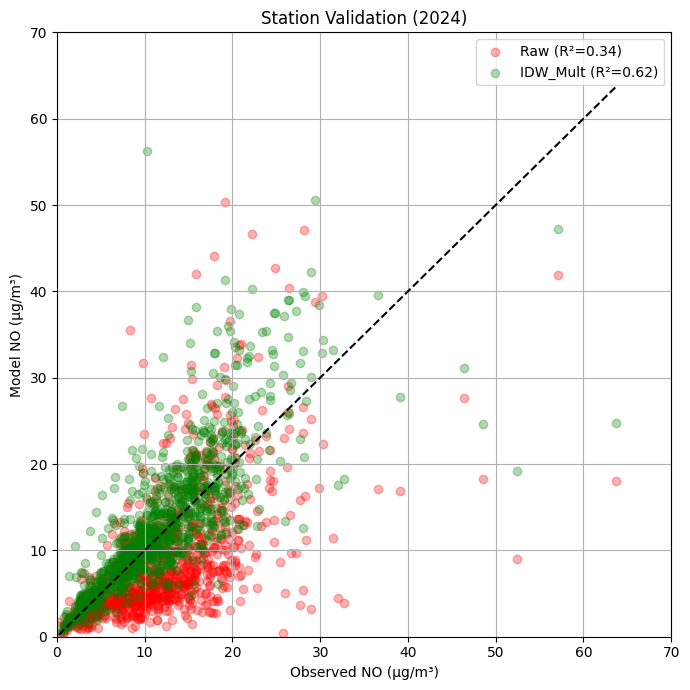

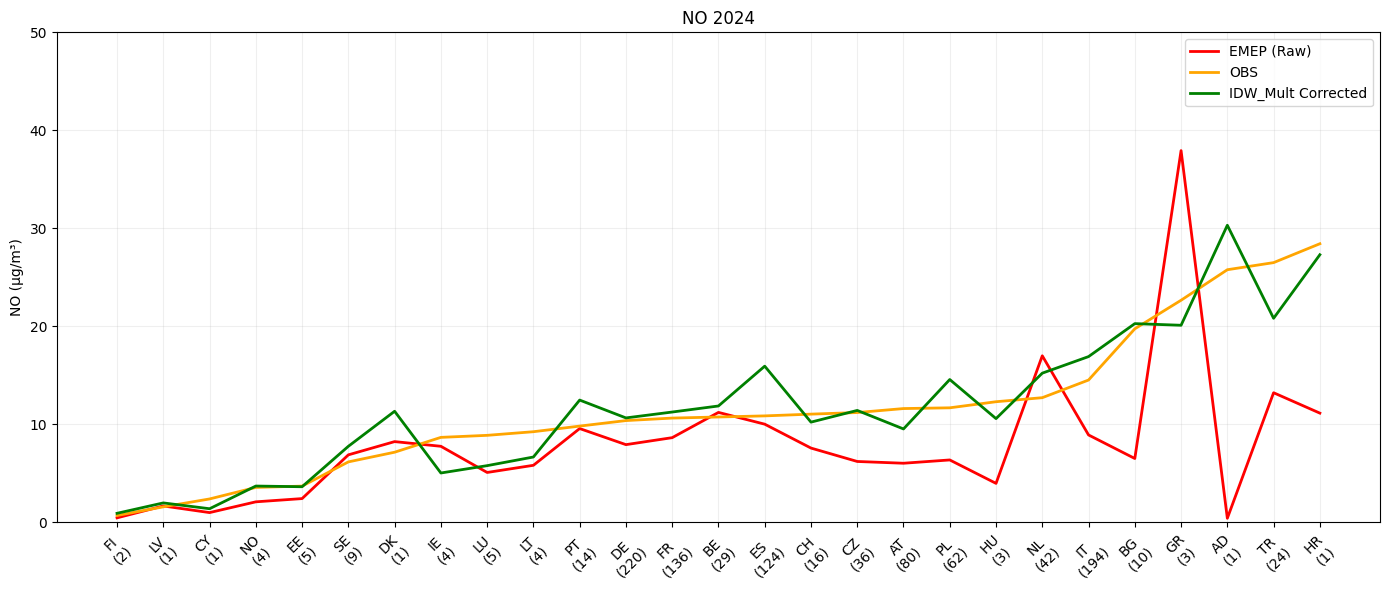

In [41]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ======================================================
# 1. LOAD MODELS
# ======================================================
ds_raw = xr.open_dataset("EMEP_yearly_2024.nc")
ds_wdi = xr.open_dataset("Scen_2024_NKUA_NO2_CSA.Cell.Mult.IDW_CORR_YEARLY.nc")

lon = ds_raw["lon"].values
lat = ds_raw["lat"].values

raw = ds_raw["SURF_ug_NO2"].values
wdi = ds_wdi["SURF_ug_NO2"].values

# handle time dimension
if raw.ndim == 3:
    raw = raw[0]
if wdi.ndim == 3:
    wdi = wdi[0]

ds_raw.close()
ds_wdi.close()

print("Shapes:", raw.shape, wdi.shape)

# ======================================================
# 2. LOAD STATIONS
# ======================================================
df = pd.read_csv("yearly_NO2_2024.csv")

if df["Longitude"].max() > 180:
    df["Longitude"] = ((df["Longitude"] + 180) % 360) - 180

df["Country"] = df["Station"].str[:2]

# ======================================================
# 3. BILINEAR INTERPOLATION
# ======================================================
def bilinear_interp(lon_pt, lat_pt, lon, lat, field):

    i = np.searchsorted(lon, lon_pt) - 1
    j = np.searchsorted(lat, lat_pt) - 1

    i = np.clip(i, 0, len(lon) - 2)
    j = np.clip(j, 0, len(lat) - 2)

    x1, x2 = lon[i], lon[i+1]
    y1, y2 = lat[j], lat[j+1]

    Q11 = field[j, i]
    Q21 = field[j, i+1]
    Q12 = field[j+1, i]
    Q22 = field[j+1, i+1]

    return (
        Q11 * (x2 - lon_pt) * (y2 - lat_pt) +
        Q21 * (lon_pt - x1) * (y2 - lat_pt) +
        Q12 * (x2 - lon_pt) * (lat_pt - y1) +
        Q22 * (lon_pt - x1) * (lat_pt - y1)
    ) / ((x2 - x1) * (y2 - y1))

# ======================================================
# 4. EXTRACT MODEL VALUES
# ======================================================
raw_vals = []
wdi_vals = []

for _, row in df.iterrows():
    lo = row["Longitude"]
    la = row["Latitude"]

    raw_vals.append(bilinear_interp(lo, la, lon, lat, raw))
    wdi_vals.append(bilinear_interp(lo, la, lon, lat, wdi))

df["Model_Raw"] = raw_vals
df["Model_WDI"] = wdi_vals

# ======================================================
# 5. CLEAN
# ======================================================
df = df.dropna(subset=["Average", "Model_Raw", "Model_WDI"])

obs = df["Average"].values
raw_vals = df["Model_Raw"].values
wdi_vals = df["Model_WDI"].values

# ======================================================
# 6. METRICS
# ======================================================
def rmse(a, b):
    return np.sqrt(np.mean((a - b)**2))

def mae(a, b):
    return np.mean(np.abs(a - b))

def bias(a, b):
    return np.mean(a - b)

def corr(a, b):
    return np.corrcoef(a, b)[0,1]

def r2_from_corr(r):
    return r**2

def r2_true(model, obs):
    ss_res = np.sum((obs - model)**2)
    ss_tot = np.sum((obs - np.mean(obs))**2)
    return 1 - ss_res / ss_tot

print("\n===== GLOBAL PERFORMANCE =====")

# compute once
r_raw = corr(raw_vals, obs)
r_wdi = corr(wdi_vals, obs)

r2_raw_corr = r2_from_corr(r_raw)
r2_wdi_corr = r2_from_corr(r_wdi)

r2_raw_true = r2_true(raw_vals, obs)
r2_wdi_true = r2_true(wdi_vals, obs)

print("\nRAW")
print("RMSE:", rmse(raw_vals, obs))
print("MAE:", mae(raw_vals, obs))
print("Bias:", bias(raw_vals, obs))
print("R:", r_raw)
print("R² (corr):", r2_raw_corr)
print("R² (true):", r2_raw_true)

print("\nADI")
print("RMSE:", rmse(wdi_vals, obs))
print("MAE:", mae(wdi_vals, obs))
print("Bias:", bias(wdi_vals, obs))
print("R:", r_wdi)
print("R² (corr):", r2_wdi_corr)
print("R² (true):", r2_wdi_true)

# ======================================================
# 7. COUNTRY METRICS
# ======================================================
results = []

for country, group in df.groupby("Country"):

    obs_c = group["Average"].values
    raw_c = group["Model_Raw"].values
    wdi_c = group["Model_WDI"].values

    r_raw_c = corr(raw_c, obs_c)
    r_wdi_c = corr(wdi_c, obs_c)

    results.append({
        "Country": country,
        "RMSE_Raw": rmse(raw_c, obs_c),
        "RMSE_WDI": rmse(wdi_c, obs_c),
        "Bias_Raw": bias(raw_c, obs_c),
        "Bias_WDI": bias(wdi_c, obs_c),
        "R2_Raw": r_raw_c**2,
        "R2_WDI": r_wdi_c**2,
        "N": len(group)
    })

metrics_df = pd.DataFrame(results).sort_values("RMSE_WDI")

print("\n===== COUNTRY METRICS =====")
print(metrics_df)

# ======================================================
# 8. SCATTER PLOT
# ======================================================
plt.figure(figsize=(7,7))

plt.scatter(obs, raw_vals,
            label=f"Raw (R²={r2_raw_corr:.2f})",
            alpha=0.3, color='red')

plt.scatter(obs, wdi_vals,
            label=f"IDW_Mult (R²={r2_wdi_corr:.2f})",
            alpha=0.3, color='green')

min_v = min(obs.min(), raw_vals.min(), wdi_vals.min())
max_v = max(obs.max(), raw_vals.max(), wdi_vals.max())

plt.plot([min_v, max_v], [min_v, max_v], 'k--')

plt.xlabel("Observed NO (μg/m³)")
plt.ylabel("Model NO (μg/m³)")
plt.title("Station Validation (2024)")
plt.xlim(0,70)
plt.ylim(0,70)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# ======================================================
# 9. COUNTRY PLOT
# ======================================================
country_mean = df.groupby("Country")[[
    "Average",
    "Model_Raw",
    "Model_WDI"
]].mean()

country_mean = country_mean.rename(columns={
    "Average": "OBS",
    "Model_Raw": "RAW",
    "Model_WDI": "WDI"
})

country_mean = country_mean.sort_values("OBS")

nstations = df.groupby("Country").size()
labels = [f"{c}\n({nstations[c]})" for c in country_mean.index]
x = np.arange(len(country_mean))

plt.figure(figsize=(14,6))

plt.plot(x, country_mean["RAW"], color='red', linewidth=2, label="EMEP (Raw)")
plt.plot(x, country_mean["OBS"], color='orange', linewidth=2, label="OBS")
plt.plot(x, country_mean["WDI"], color='green', linewidth=2, label="IDW_Mult Corrected")

plt.xticks(x, labels, rotation=45)
plt.ylabel("NO (μg/m³)")
plt.title("NO 2024")
plt.ylim(0,50)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

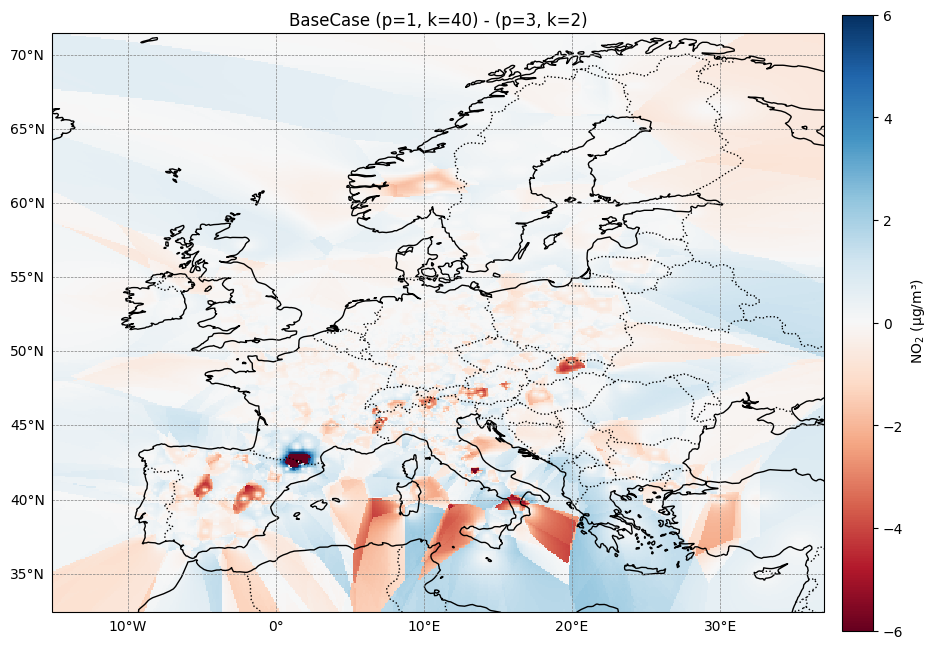

In [73]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# ======================================================
# 1. LOAD FILES
# ======================================================
corrected_path = "BaseCase_NO2_Y_IDW_MUL.nc" #A
reference_path = "BaseCase_NO2_3_2_IDW_MUL.nc"  #B

ds_corrected = xr.open_dataset(corrected_path)
ds_reference = xr.open_dataset(reference_path)

# ======================================================
# 2. EXTRACT VARIABLES
# ======================================================
corrected = ds_corrected["Interpolated_Bias"].squeeze().values
reference = ds_reference["Interpolated_Bias"].squeeze().values

# Coordinates (same grid assumed)
lon = ds_corrected["lon"].values
lat = ds_corrected["lat"].values

Lon, Lat = np.meshgrid(lon, lat)

# ======================================================
# 3. COMPUTE DIFFERENCE A-B
# ======================================================
diff = corrected - reference


# 4. COLOR SCALE (MANUAL)
# ======================================================
vmax = 6   # <-- adjust this
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

# Optional: clip extremes
diff = np.clip(diff, -vmax, vmax)
# ======================================================
# 5. PLOT
# ======================================================
fig, ax = plt.subplots(figsize=(12, 8),
                       subplot_kw={'projection': ccrs.PlateCarree()})

mesh = ax.pcolormesh(
    Lon, Lat, diff,
    cmap='RdBu',
    shading='auto',
    transform=ccrs.PlateCarree(),
    norm=norm
)

# Colorbar
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label(" NO$_{2}$ (µg/m³)")

# Map features
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Gridlines
gl = ax.gridlines(draw_labels=True, linestyle="--",
                  linewidth=0.5, color="gray")
gl.top_labels = False
gl.right_labels = False

# Labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("BaseCase (p=1, k=40) - (p=3, k=2)")

plt.show()

# ======================================================
# 6. CLOSE FILES
# ======================================================
ds_corrected.close()
ds_reference.close()

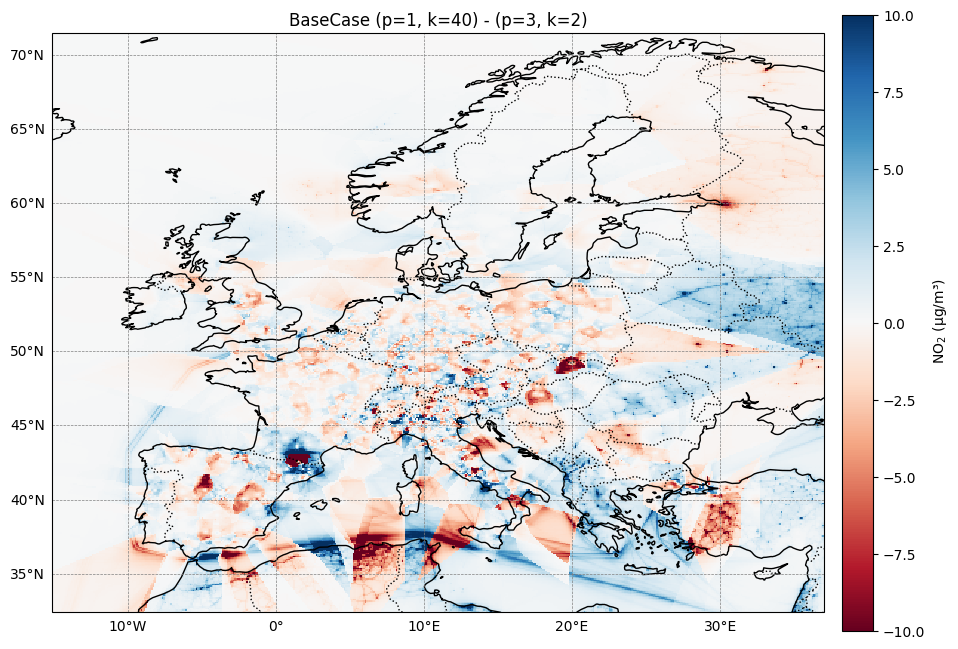

In [62]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# ======================================================
# 1. LOAD FILES
# ======================================================
corrected_path = "BaseCase_NKUA_NO2_CSA.Cell.Mult.IDW_CORR_YEARLY.nc" #A
reference_path = "BaseCase_3_2_NO2_CSA.Cell.Mult.IDW_CORR_YEARLY.nc"  #B

ds_corrected = xr.open_dataset(corrected_path)
ds_reference = xr.open_dataset(reference_path)

# ======================================================
# 2. EXTRACT VARIABLES
# ======================================================
corrected = ds_corrected["SURF_ug_NO2"].squeeze().values
reference = ds_reference["SURF_ug_NO2"].squeeze().values

# Coordinates (same grid assumed)
lon = ds_corrected["lon"].values
lat = ds_corrected["lat"].values

Lon, Lat = np.meshgrid(lon, lat)

# ======================================================
# 3. COMPUTE DIFFERENCE A-B
# ======================================================
diff = corrected - reference


# 4. COLOR SCALE (MANUAL)
# ======================================================
vmax = 10   # <-- adjust this
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

# Optional: clip extremes
diff = np.clip(diff, -vmax, vmax)
# ======================================================
# 5. PLOT
# ======================================================
fig, ax = plt.subplots(figsize=(12, 8),
                       subplot_kw={'projection': ccrs.PlateCarree()})

mesh = ax.pcolormesh(
    Lon, Lat, diff,
    cmap='RdBu',
    shading='auto',
    transform=ccrs.PlateCarree(),
    norm=norm
)

# Colorbar
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label(" NO$_{2}$ (µg/m³)")

# Map features
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Gridlines
gl = ax.gridlines(draw_labels=True, linestyle="--",
                  linewidth=0.5, color="gray")
gl.top_labels = False
gl.right_labels = False

# Labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("BaseCase (p=1, k=40) - (p=3, k=2)")

plt.show()

# ======================================================
# 6. CLOSE FILES
# ======================================================
ds_corrected.close()
ds_reference.close()

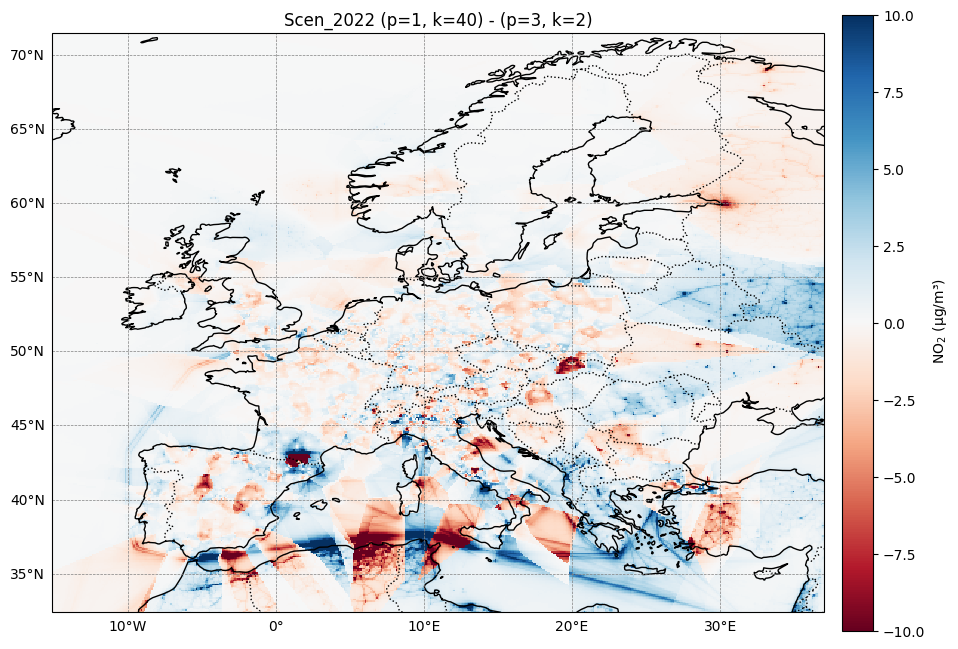

In [64]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# ======================================================
# 1. LOAD FILES
# ======================================================
corrected_path = "Scen_2022_NKUA_NO2_CSA.Cell.Mult.IDW_CORR_YEARLY.nc"
reference_path = "Scen_2022_3_2_NO2_CSA.Cell.Mult.IDW_CORR_YEARLY.nc"  # <-- your base file

ds_corrected = xr.open_dataset(corrected_path)
ds_reference = xr.open_dataset(reference_path)

# ======================================================
# 2. EXTRACT VARIABLES
# ======================================================
corrected = ds_corrected["SURF_ug_NO2"].squeeze().values
reference = ds_reference["SURF_ug_NO2"].squeeze().values

# Coordinates (same grid assumed)
lon = ds_corrected["lon"].values
lat = ds_corrected["lat"].values

Lon, Lat = np.meshgrid(lon, lat)

# ======================================================
# 3. COMPUTE DIFFERENCE
# ======================================================
diff = corrected - reference


# 4. COLOR SCALE (MANUAL)
# ======================================================
vmax = 10   # <-- adjust this
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

# Optional: clip extremes
diff = np.clip(diff, -vmax, vmax)
# ======================================================
# 5. PLOT
# ======================================================
fig, ax = plt.subplots(figsize=(12, 8),
                       subplot_kw={'projection': ccrs.PlateCarree()})

mesh = ax.pcolormesh(
    Lon, Lat, diff,
    cmap='RdBu',
    shading='auto',
    transform=ccrs.PlateCarree(),
    norm=norm
)

# Colorbar
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label(" NO$_{2}$ (µg/m³)")

# Map features
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Gridlines
gl = ax.gridlines(draw_labels=True, linestyle="--",
                  linewidth=0.5, color="gray")
gl.top_labels = False
gl.right_labels = False

# Labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Scen_2022 (p=1, k=40) - (p=3, k=2)")

plt.show()

# ======================================================
# 6. CLOSE FILES
# ======================================================
ds_corrected.close()
ds_reference.close()

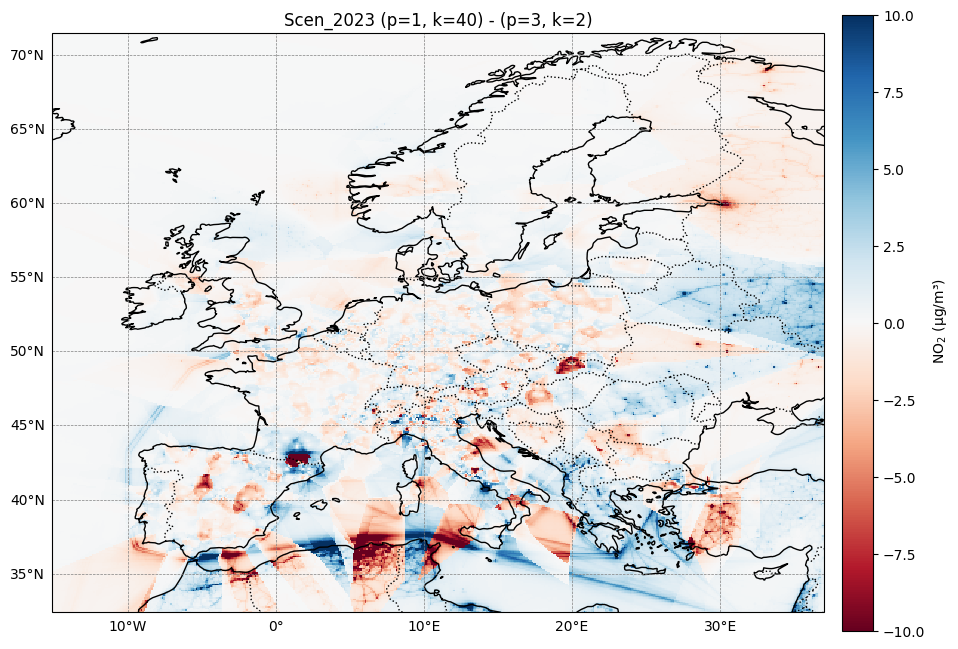

In [68]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# ======================================================
# 1. LOAD FILES
# ======================================================
corrected_path = "Scen_2023_NKUA_NO2_CSA.Cell.Mult.IDW_CORR_YEARLY.nc"
reference_path = "Scen_2023_3_2_NO2_CSA.Cell.Mult.IDW_CORR_YEARLY.nc"  # <-- your base file

ds_corrected = xr.open_dataset(corrected_path)
ds_reference = xr.open_dataset(reference_path)

# ======================================================
# 2. EXTRACT VARIABLES
# ======================================================
corrected = ds_corrected["SURF_ug_NO2"].squeeze().values
reference = ds_reference["SURF_ug_NO2"].squeeze().values

# Coordinates (same grid assumed)
lon = ds_corrected["lon"].values
lat = ds_corrected["lat"].values

Lon, Lat = np.meshgrid(lon, lat)

# ======================================================
# 3. COMPUTE DIFFERENCE
# ======================================================
diff = corrected - reference


# 4. COLOR SCALE (MANUAL)
# ======================================================
vmax = 10   # <-- adjust this
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

# Optional: clip extremes
diff = np.clip(diff, -vmax, vmax)
# ======================================================
# 5. PLOT
# ======================================================
fig, ax = plt.subplots(figsize=(12, 8),
                       subplot_kw={'projection': ccrs.PlateCarree()})

mesh = ax.pcolormesh(
    Lon, Lat, diff,
    cmap='RdBu',
    shading='auto',
    transform=ccrs.PlateCarree(),
    norm=norm
)

# Colorbar
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label(" NO$_{2}$ (µg/m³)")

# Map features
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Gridlines
gl = ax.gridlines(draw_labels=True, linestyle="--",
                  linewidth=0.5, color="gray")
gl.top_labels = False
gl.right_labels = False

# Labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Scen_2023 (p=1, k=40) - (p=3, k=2)")

plt.show()

# ======================================================
# 6. CLOSE FILES
# ======================================================
ds_corrected.close()
ds_reference.close()

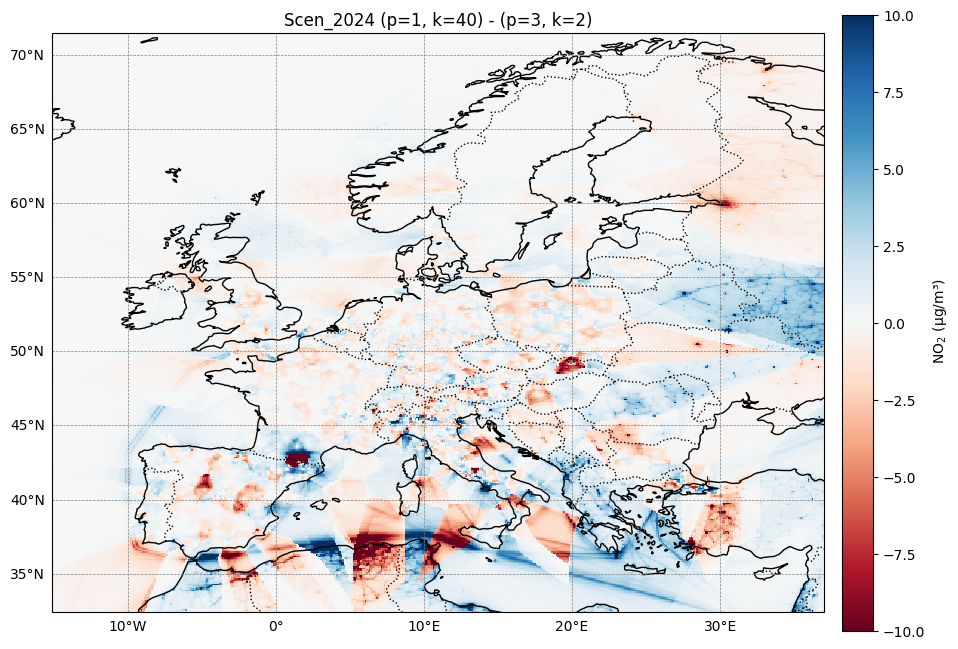

In [67]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# ======================================================
# 1. LOAD FILES
# ======================================================
corrected_path = "Scen_2024_NKUA_NO2_CSA.Cell.Mult.IDW_CORR_YEARLY.nc"
reference_path = "Scen_2024_3_2_NO2_CSA.Cell.Mult.IDW_CORR_YEARLY.nc"  # <-- your base file

ds_corrected = xr.open_dataset(corrected_path)
ds_reference = xr.open_dataset(reference_path)

# ======================================================
# 2. EXTRACT VARIABLES
# ======================================================
corrected = ds_corrected["SURF_ug_NO2"].squeeze().values
reference = ds_reference["SURF_ug_NO2"].squeeze().values

# Coordinates (same grid assumed)
lon = ds_corrected["lon"].values
lat = ds_corrected["lat"].values

Lon, Lat = np.meshgrid(lon, lat)

# ======================================================
# 3. COMPUTE DIFFERENCE
# ======================================================
diff = corrected - reference


# 4. COLOR SCALE (MANUAL)
# ======================================================
vmax = 10   # <-- adjust this
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

# Optional: clip extremes
diff = np.clip(diff, -vmax, vmax)
# ======================================================
# 5. PLOT
# ======================================================
fig, ax = plt.subplots(figsize=(12, 8),
                       subplot_kw={'projection': ccrs.PlateCarree()})

mesh = ax.pcolormesh(
    Lon, Lat, diff,
    cmap='RdBu',
    shading='auto',
    transform=ccrs.PlateCarree(),
    norm=norm
)

# Colorbar
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label(" NO$_{2}$ (µg/m³)")

# Map features
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Gridlines
gl = ax.gridlines(draw_labels=True, linestyle="--",
                  linewidth=0.5, color="gray")
gl.top_labels = False
gl.right_labels = False

# Labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Scen_2024 (p=1, k=40) - (p=3, k=2)")

plt.show()

# ======================================================
# 6. CLOSE FILES
# ======================================================
ds_corrected.close()
ds_reference.close()

Shapes: (391, 521) (391, 521) (391, 521)

===== GLOBAL PERFORMANCE =====

RAW
RMSE: 9.75942406856348
MAE: 7.55685349179529
Bias: -6.317512854057136
R: 0.6809700825471148
R² (corr): 0.4637202533242243
R² (true): -0.01650385720215719

ADI
RMSE: 3.5642135090517346
MAE: 2.1208854326483833
Bias: -0.6048465866157392
R: 0.9318406525187171
R² (corr): 0.8683270016865083
R² (true): 0.8644223581319099

SECOND SCENARIO
RMSE: 3.606847253272114
MAE: 2.1066495027494003
Bias: -0.7307065822703113
R: 0.9310525101863841
R² (corr): 0.866858776724367
R² (true): 0.8611595049694849

===== COUNTRY METRICS =====
   Country   RMSE_Raw   RMSE_WDI  RMSE_WDI2   Bias_Raw  Bias_WDI  Bias_WDI2  \
5       CY   0.375192   0.022854   0.021764  -0.375192  0.022854   0.021764   
11      FI   0.565070   0.030879   0.032189  -0.562822  0.023660   0.025440   
30      SI   0.378095   0.134065   0.058294   0.378095  0.134065   0.058294   
0       AD  26.214681   0.195744   4.229599 -26.214681 -0.195744   4.229599   
17      IE

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


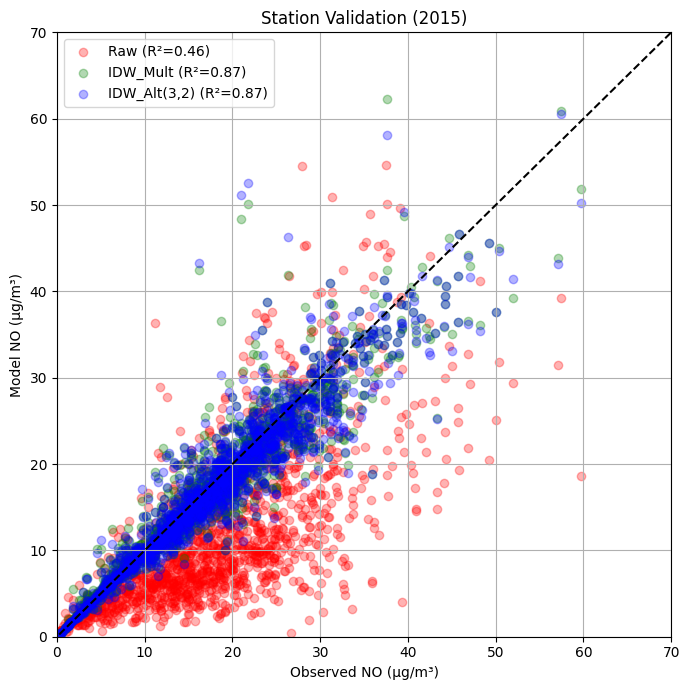

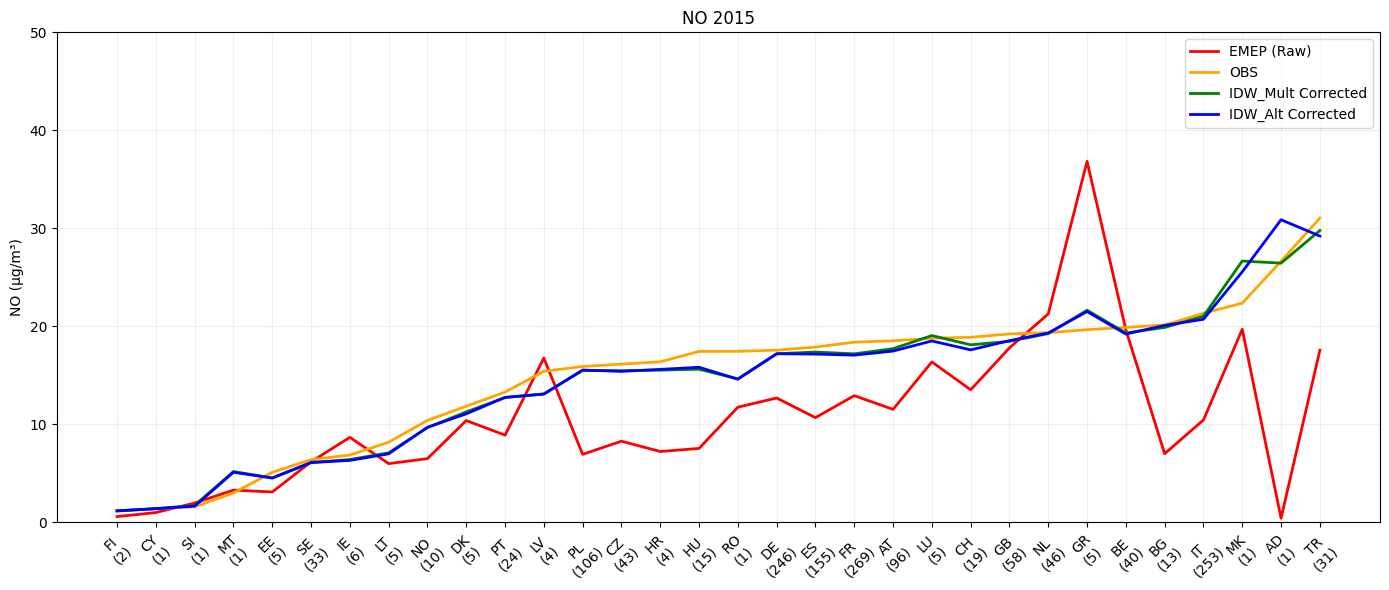

In [75]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ======================================================
# 1. LOAD MODELS
# ======================================================
ds_raw = xr.open_dataset("EMEP_yearly_2015.nc")
ds_wdi = xr.open_dataset("BaseCase_NKUA_NO2_CSA.Cell.Mult.IDW_CORR_YEARLY.nc")
ds_wdi2 = xr.open_dataset("BaseCase_3_2_NO2_CSA.Cell.Mult.IDW_CORR_YEARLY.nc")

lon = ds_raw["lon"].values
lat = ds_raw["lat"].values

raw = ds_raw["SURF_ug_NO2"].values
wdi = ds_wdi["SURF_ug_NO2"].values
wdi2 = ds_wdi2["SURF_ug_NO2"].values   # 🔴 NEW

# handle time dimension
if raw.ndim == 3:
    raw = raw[0]
if wdi.ndim == 3:
    wdi = wdi[0]
if wdi2.ndim == 3:                    # 🔴 NEW
    wdi2 = wdi2[0]

ds_raw.close()
ds_wdi.close()
ds_wdi2.close()                       # 🔴 NEW

print("Shapes:", raw.shape, wdi.shape, wdi2.shape)

# ======================================================
# 2. LOAD STATIONS
# ======================================================
df = pd.read_csv("yearly_NO2_2015.csv")

if df["Longitude"].max() > 180:
    df["Longitude"] = ((df["Longitude"] + 180) % 360) - 180

df["Country"] = df["Station"].str[:2]

# ======================================================
# 3. BILINEAR INTERPOLATION
# ======================================================
def bilinear_interp(lon_pt, lat_pt, lon, lat, field):

    i = np.searchsorted(lon, lon_pt) - 1
    j = np.searchsorted(lat, lat_pt) - 1

    i = np.clip(i, 0, len(lon) - 2)
    j = np.clip(j, 0, len(lat) - 2)

    x1, x2 = lon[i], lon[i+1]
    y1, y2 = lat[j], lat[j+1]

    Q11 = field[j, i]
    Q21 = field[j, i+1]
    Q12 = field[j+1, i]
    Q22 = field[j+1, i+1]

    return (
        Q11 * (x2 - lon_pt) * (y2 - lat_pt) +
        Q21 * (lon_pt - x1) * (y2 - lat_pt) +
        Q12 * (x2 - lon_pt) * (lat_pt - y1) +
        Q22 * (lon_pt - x1) * (lat_pt - y1)
    ) / ((x2 - x1) * (y2 - y1))

# ======================================================
# 4. EXTRACT MODEL VALUES
# ======================================================
raw_vals = []
wdi_vals = []
wdi2_vals = []   # 🔴 NEW

for _, row in df.iterrows():
    lo = row["Longitude"]
    la = row["Latitude"]

    raw_vals.append(bilinear_interp(lo, la, lon, lat, raw))
    wdi_vals.append(bilinear_interp(lo, la, lon, lat, wdi))
    wdi2_vals.append(bilinear_interp(lo, la, lon, lat, wdi2))  # 🔴 NEW

df["Model_Raw"] = raw_vals
df["Model_WDI"] = wdi_vals
df["Model_WDI2"] = wdi2_vals   # 🔴 NEW

# ======================================================
# 5. CLEAN
# ======================================================
df = df.dropna(subset=["Average", "Model_Raw", "Model_WDI", "Model_WDI2"])

obs = df["Average"].values
raw_vals = df["Model_Raw"].values
wdi_vals = df["Model_WDI"].values
wdi2_vals = df["Model_WDI2"].values

# ======================================================
# 6. METRICS
# ======================================================
def rmse(a, b):
    return np.sqrt(np.mean((a - b)**2))

def mae(a, b):
    return np.mean(np.abs(a - b))

def bias(a, b):
    return np.mean(a - b)

def corr(a, b):
    return np.corrcoef(a, b)[0,1]

def r2_from_corr(r):
    return r**2

def r2_true(model, obs):
    ss_res = np.sum((obs - model)**2)
    ss_tot = np.sum((obs - np.mean(obs))**2)
    return 1 - ss_res / ss_tot

print("\n===== GLOBAL PERFORMANCE =====")

# compute once
r_raw = corr(raw_vals, obs)
r_wdi = corr(wdi_vals, obs)
r_wdi2 = corr(wdi2_vals, obs)   # 🔴 NEW

r2_raw_corr = r2_from_corr(r_raw)
r2_wdi_corr = r2_from_corr(r_wdi)
r2_wdi2_corr = r2_from_corr(r_wdi2)   # 🔴 NEW

r2_raw_true = r2_true(raw_vals, obs)
r2_wdi_true = r2_true(wdi_vals, obs)
r2_wdi2_true = r2_true(wdi2_vals, obs)   # 🔴 NEW

print("\nRAW")
print("RMSE:", rmse(raw_vals, obs))
print("MAE:", mae(raw_vals, obs))
print("Bias:", bias(raw_vals, obs))
print("R:", r_raw)
print("R² (corr):", r2_raw_corr)
print("R² (true):", r2_raw_true)

print("\nADI")
print("RMSE:", rmse(wdi_vals, obs))
print("MAE:", mae(wdi_vals, obs))
print("Bias:", bias(wdi_vals, obs))
print("R:", r_wdi)
print("R² (corr):", r2_wdi_corr)
print("R² (true):", r2_wdi_true)

print("\nSECOND SCENARIO")   # 🔴 NEW
print("RMSE:", rmse(wdi2_vals, obs))
print("MAE:", mae(wdi2_vals, obs))
print("Bias:", bias(wdi2_vals, obs))
print("R:", r_wdi2)
print("R² (corr):", r2_wdi2_corr)
print("R² (true):", r2_wdi2_true)

# ======================================================
# 7. COUNTRY METRICS
# ======================================================
results = []

for country, group in df.groupby("Country"):

    obs_c = group["Average"].values
    raw_c = group["Model_Raw"].values
    wdi_c = group["Model_WDI"].values
    wdi2_c = group["Model_WDI2"].values   # 🔴 NEW

    r_raw_c = corr(raw_c, obs_c)
    r_wdi_c = corr(wdi_c, obs_c)
    r_wdi2_c = corr(wdi2_c, obs_c)   # 🔴 NEW

    results.append({
        "Country": country,
        "RMSE_Raw": rmse(raw_c, obs_c),
        "RMSE_WDI": rmse(wdi_c, obs_c),
        "RMSE_WDI2": rmse(wdi2_c, obs_c),   # 🔴 NEW
        "Bias_Raw": bias(raw_c, obs_c),
        "Bias_WDI": bias(wdi_c, obs_c),
        "Bias_WDI2": bias(wdi2_c, obs_c),   # 🔴 NEW
        "R2_Raw": r_raw_c**2,
        "R2_WDI": r_wdi_c**2,
        "R2_WDI2": r_wdi2_c**2,   # 🔴 NEW
        "N": len(group)
    })

metrics_df = pd.DataFrame(results).sort_values("RMSE_WDI")

print("\n===== COUNTRY METRICS =====")
print(metrics_df)

# ======================================================
# 8. SCATTER PLOT
# ======================================================
plt.figure(figsize=(7,7))

plt.scatter(obs, raw_vals,
            label=f"Raw (R²={r2_raw_corr:.2f})",
            alpha=0.3, color='red')

plt.scatter(obs, wdi_vals,
            label=f"IDW_Mult (R²={r2_wdi_corr:.2f})",
            alpha=0.3, color='green')

plt.scatter(obs, wdi2_vals,
            label=f"IDW_Alt(3,2) (R²={r2_wdi2_corr:.2f})",
            alpha=0.3, color='blue')   # 🔴 NEW

min_v = min(obs.min(), raw_vals.min(), wdi_vals.min(), wdi2_vals.min())
max_v = max(obs.max(), raw_vals.max(), wdi_vals.max(), wdi2_vals.max())

plt.plot([min_v, max_v], [min_v, max_v], 'k--')

plt.xlabel("Observed NO (μg/m³)")
plt.ylabel("Model NO (μg/m³)")
plt.title("Station Validation (2015)")
plt.xlim(0,70)
plt.ylim(0,70)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# ======================================================
# 9. COUNTRY PLOT
# ======================================================
country_mean = df.groupby("Country")[[
    "Average",
    "Model_Raw",
    "Model_WDI",
    "Model_WDI2"
]].mean()

country_mean = country_mean.rename(columns={
    "Average": "OBS",
    "Model_Raw": "RAW",
    "Model_WDI": "WDI",
    "Model_WDI2": "WDI2"
})

country_mean = country_mean.sort_values("OBS")

nstations = df.groupby("Country").size()
labels = [f"{c}\n({nstations[c]})" for c in country_mean.index]
x = np.arange(len(country_mean))

plt.figure(figsize=(14,6))

plt.plot(x, country_mean["RAW"], color='red', linewidth=2, label="EMEP (Raw)")
plt.plot(x, country_mean["OBS"], color='orange', linewidth=2, label="OBS")
plt.plot(x, country_mean["WDI"], color='green', linewidth=2, label="IDW_Mult Corrected")
plt.plot(x, country_mean["WDI2"], color='blue', linewidth=2, label="IDW_Alt Corrected")

plt.xticks(x, labels, rotation=45)
plt.ylabel("NO (μg/m³)")
plt.title("NO 2015")
plt.ylim(0,50)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [5]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import os
from sklearn.neighbors import BallTree

# ======================================================
# PARAMETERS
# ======================================================
p = 2
k_values = np.arange(2, 41, 1)

# 🔴 FIXED REFERENCE (DO NOT CHANGE)
p_ref = 2
k_ref = 40

ymin, ymax = 0, 70

plt.rcParams['figure.dpi'] = 120

# ======================================================
# LOAD DATA
# ======================================================
ds15 = xr.open_dataset("EMEP_yearly_2015.nc")
lon = ds15["lon"].values
lat = ds15["lat"].values
raw15 = ds15["SURF_ug_NO2"].values
if raw15.ndim == 3:
    raw15 = raw15[0]
ds15.close()

ds22 = xr.open_dataset("EMEP_yearly_2022.nc")
raw22 = ds22["SURF_ug_NO2"].values
if raw22.ndim == 3:
    raw22 = raw22[0]
ds22.close()

# ======================================================
# BIAS DATA
# ======================================================
df_bias = pd.read_csv("baseNO2_gridcell_average.csv")
df_bias["bias_ratio"] = df_bias["SURF_ug_NO2"] / df_bias["nearest_SURF_ug_NO2"]

cell_points = np.column_stack([
    np.radians(df_bias["nearest_grid_lat"].values),
    np.radians(df_bias["nearest_grid_lon"].values)
])

bias_values = df_bias["bias_ratio"].values

lon_mesh, lat_mesh = np.meshgrid(lon, lat)
grid_points = np.column_stack([
    np.radians(lat_mesh.ravel()),
    np.radians(lon_mesh.ravel())
])

tree = BallTree(cell_points, metric="haversine")

# ======================================================
# STATIONS
# ======================================================
df15 = pd.read_csv("yearly_NO2_2015.csv")
df22 = pd.read_csv("yearly_NO2_2022.csv")

for df in [df15, df22]:
    if df["Longitude"].max() > 180:
        df["Longitude"] = ((df["Longitude"] + 180) % 360) - 180
    df["Country"] = df["Station"].str[:2]

# ======================================================
# FUNCTIONS
# ======================================================
def run_idw(p, k):
    dists, idxs = tree.query(grid_points, k=k)
    dists = np.maximum(dists, 1e-12)

    weights = 1 / (dists**p)
    weights /= weights.sum(axis=1, keepdims=True)

    bias_field = np.sum(weights * bias_values[idxs], axis=1)
    return bias_field.reshape(raw15.shape)

def bilinear_interp(lon_pt, lat_pt, lon, lat, field):
    i = np.searchsorted(lon, lon_pt) - 1
    j = np.searchsorted(lat, lat_pt) - 1

    i = np.clip(i, 0, len(lon)-2)
    j = np.clip(j, 0, len(lat)-2)

    x1, x2 = lon[i], lon[i+1]
    y1, y2 = lat[j], lat[j+1]

    Q11 = field[j, i]
    Q21 = field[j, i+1]
    Q12 = field[j+1, i]
    Q22 = field[j+1, i+1]

    return (
        Q11 * (x2 - lon_pt) * (y2 - lat_pt) +
        Q21 * (lon_pt - x1) * (y2 - lat_pt) +
        Q12 * (x2 - lon_pt) * (lat_pt - y1) +
        Q22 * (lon_pt - x1) * (lat_pt - y1)
    ) / ((x2 - x1) * (y2 - y1))

def compute_country(df, field, col_name):
    vals = []
    for _, row in df.iterrows():
        lo, la = row["Longitude"], row["Latitude"]
        vals.append(bilinear_interp(lo, la, lon, lat, field))

    df[col_name] = vals

    country = df.groupby("Country")[["Average", col_name]].mean()
    country = country.rename(columns={"Average": "Observations"})
    country = country.sort_values("Observations")

    return country

# ======================================================
# 🔴 FIXED REFERENCE MODEL (p=2, k=40)
# ======================================================
bias_ref = np.maximum(run_idw(p_ref, k_ref), 0.1)

model15_ref = raw15 * bias_ref
model22_ref = raw22 * bias_ref

country15_ref = compute_country(df15.copy(), model15_ref, "IDW_Mult")
country22_ref = compute_country(df22.copy(), model22_ref, "IDW_Mult")

# ======================================================
# OUTPUT
# ======================================================
os.makedirs("frames", exist_ok=True)
frames = []

# ======================================================
# LOOP OVER k
# ======================================================
for k in k_values:

    print(f"Running k={k}")

    bias = np.maximum(run_idw(p, k), 0.1)

    model15 = raw15 * bias
    model22 = raw22 * bias

    country15 = compute_country(df15.copy(), model15, "Model")
    country22 = compute_country(df22.copy(), model22, "Model")

    # ======================================================
    # PLOT
    # ======================================================
    fig, axs = plt.subplots(2,1, figsize=(10,8))
    fig.suptitle(f"IDW Sensitivity (p={p}, k={k})", fontsize=16)

    x1 = np.arange(len(country15))

    # --- BASECASE ---
    axs[0].plot(x1, country15["Observations"],
                color='orange', linewidth=1.6, label="Observations")

    axs[0].plot(x1, country15["Model"],
                color='blue', linewidth=1.4, label=f"Model (k={k})")

    axs[0].plot(x1, country15_ref["IDW_Mult"],
                color='red', linestyle='--',
                linewidth=1.2, label="Reference (p=2, k=40)")

    axs[0].text(0.02, 0.85, f"k={k}",
                transform=axs[0].transAxes,
                fontsize=14, weight='bold')

    axs[0].set_ylim(ymin, ymax)
    axs[0].set_title("BaseCase 2015")
    axs[0].legend()
    axs[0].grid(alpha=0.3)

    # --- SCENARIO ---
    x2 = np.arange(len(country22))

    axs[1].plot(x2, country22["Observations"],
                color='orange', linewidth=1.6, label="Observations")

    axs[1].plot(x2, country22["Model"],
                color='green', linewidth=1.4, label=f"Model (k={k})")

    axs[1].plot(x2, country22_ref["IDW_Mult"],
                color='red', linestyle='--',
                linewidth=1.2, label="Reference (p=2, k=40)")

    axs[1].set_ylim(ymin, ymax)
    axs[1].set_title("Scenario 2022")
    axs[1].legend()
    axs[1].grid(alpha=0.3)

    plt.tight_layout()

    fname = f"frames/frame_k{k}.png"
    plt.savefig(fname)
    plt.close()

    frames.append(imageio.imread(fname))

# ======================================================
# CREATE GIF
# ======================================================
imageio.mimsave("COUNTRY_IDW_EVOLUTION.gif", frames, duration=1.2)

print("GIF READY: COUNTRY_IDW_EVOLUTION.gif")

Running k=2
Running k=3
Running k=4
Running k=5
Running k=6
Running k=7
Running k=8
Running k=9
Running k=10
Running k=11
Running k=12
Running k=13
Running k=14
Running k=15
Running k=16
Running k=17
Running k=18
Running k=19
Running k=20
Running k=21
Running k=22
Running k=23
Running k=24
Running k=25
Running k=26
Running k=27
Running k=28
Running k=29
Running k=30
Running k=31
Running k=32
Running k=33
Running k=34
Running k=35
Running k=36
Running k=37
Running k=38
Running k=39
Running k=40
GIF READY: COUNTRY_IDW_EVOLUTION.gif


In [6]:
import moviepy.editor as mp
import glob

# Load frames in correct order
frame_files = sorted(
    glob.glob("frames/frame_k*.png"),
    key=lambda x: int(x.split("k")[1].split(".")[0])
)

# Create smooth video (VERY important: proper fps)
clip = mp.ImageSequenceClip(frame_files, fps=1)  # 1 frame/sec

clip.write_videofile(
    "COUNTRY_IDW_EVOLUTION.mp4",
    codec="libx264",
    bitrate="5000k"   # improves quality
)

Moviepy - Building video COUNTRY_IDW_EVOLUTION.mp4.
Moviepy - Writing video COUNTRY_IDW_EVOLUTION.mp4



Moviepy - Done !
Moviepy - video ready COUNTRY_IDW_EVOLUTION.mp4


In [19]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import os
from sklearn.neighbors import BallTree

# ======================================================
# PARAMETERS
# ======================================================
p_values = np.arange(0.5, 3.1, 0.25)
k = 5

p_ref = 1.1
k_ref = 40

ymin, ymax = 0, 70

plt.rcParams['figure.dpi'] = 120

# ======================================================
# LOAD DATA
# ======================================================
ds15 = xr.open_dataset("EMEP_yearly_2015.nc")
lon = ds15["lon"].values
lat = ds15["lat"].values
raw15 = ds15["SURF_ug_NO2"].values
if raw15.ndim == 3:
    raw15 = raw15[0]
ds15.close()

ds22 = xr.open_dataset("EMEP_yearly_2022.nc")
raw22 = ds22["SURF_ug_NO2"].values
if raw22.ndim == 3:
    raw22 = raw22[0]
ds22.close()

# ======================================================
# BIAS DATA
# ======================================================
df_bias = pd.read_csv("baseNO2_gridcell_average.csv")
df_bias["bias_ratio"] = df_bias["SURF_ug_NO2"] / df_bias["nearest_SURF_ug_NO2"]

cell_points = np.column_stack([
    np.radians(df_bias["nearest_grid_lat"].values),
    np.radians(df_bias["nearest_grid_lon"].values)
])

bias_values = df_bias["bias_ratio"].values

lon_mesh, lat_mesh = np.meshgrid(lon, lat)
grid_points = np.column_stack([
    np.radians(lat_mesh.ravel()),
    np.radians(lon_mesh.ravel())
])

tree = BallTree(cell_points, metric="haversine")

# ======================================================
# STATIONS
# ======================================================
df15 = pd.read_csv("yearly_NO2_2015.csv")
df22 = pd.read_csv("yearly_NO2_2022.csv")

for df in [df15, df22]:
    if df["Longitude"].max() > 180:
        df["Longitude"] = ((df["Longitude"] + 180) % 360) - 180
    df["Country"] = df["Station"].str[:2]

# ======================================================
# FUNCTIONS
# ======================================================
def run_idw(p, k):
    dists, idxs = tree.query(grid_points, k=k)
    dists = np.maximum(dists, 1e-12)

    weights = 1 / (dists**p)
    weights /= weights.sum(axis=1, keepdims=True)

    bias_field = np.sum(weights * bias_values[idxs], axis=1)
    return bias_field.reshape(raw15.shape)

def bilinear_interp(lon_pt, lat_pt, lon, lat, field):
    i = np.searchsorted(lon, lon_pt) - 1
    j = np.searchsorted(lat, lat_pt) - 1

    i = np.clip(i, 0, len(lon)-2)
    j = np.clip(j, 0, len(lat)-2)

    x1, x2 = lon[i], lon[i+1]
    y1, y2 = lat[j], lat[j+1]

    Q11 = field[j, i]
    Q21 = field[j, i+1]
    Q12 = field[j+1, i]
    Q22 = field[j+1, i+1]

    return (
        Q11 * (x2 - lon_pt) * (y2 - lat_pt) +
        Q21 * (lon_pt - x1) * (y2 - lat_pt) +
        Q12 * (x2 - lon_pt) * (lat_pt - y1) +
        Q22 * (lon_pt - x1) * (lat_pt - y1)
    ) / ((x2 - x1) * (y2 - y1))

def compute_country(df, field, col_name):
    vals = []
    for _, row in df.iterrows():
        lo, la = row["Longitude"], row["Latitude"]
        vals.append(bilinear_interp(lo, la, lon, lat, field))

    df[col_name] = vals

    country = df.groupby("Country")[["Average", col_name]].mean()
    country = country.rename(columns={"Average": "Observations"})
    country = country.sort_values("Observations")

    return country

# ======================================================
# 🔴 FIXED REFERENCE MODEL (p=2, k=40)
# ======================================================
bias_ref = np.maximum(run_idw(p_ref, k_ref), 0.1)

model15_ref = raw15 * bias_ref
model22_ref = raw22 * bias_ref

country15_ref = compute_country(df15.copy(), model15_ref, "IDW_Mult")
country22_ref = compute_country(df22.copy(), model22_ref, "IDW_Mult")

# ======================================================
# OUTPUT
# ======================================================
os.makedirs("frames", exist_ok=True)
frames = []

# ======================================================
# LOOP OVER p (ONLY CHANGE)
# ======================================================
for p in p_values:

    print(f"Running p={p}")

    bias = np.maximum(run_idw(p, k), 0.1)

    model15 = raw15 * bias
    model22 = raw22 * bias

    country15 = compute_country(df15.copy(), model15, "Model")
    country22 = compute_country(df22.copy(), model22, "Model")

    # ======================================================
    # PLOT (UNCHANGED STYLE)
    # ======================================================
    fig, axs = plt.subplots(2,1, figsize=(10,8))
    fig.suptitle(f"IDW Sensitivity (p={p}, k={k})", fontsize=16)

    x1 = np.arange(len(country15))

    axs[0].plot(x1, country15["Observations"],
                color='orange', linewidth=1.6, label="Observations")

    axs[0].plot(x1, country15["Model"],
                color='blue', linewidth=1.4, label=f"Model (p={p})")

    axs[0].plot(x1, country15_ref["IDW_Mult"],
                color='red', linestyle='--',
                linewidth=1.2, label="Reference (p=2, k=40)")

    axs[0].text(0.02, 0.85, f"p={p}",
                transform=axs[0].transAxes,
                fontsize=14, weight='bold')

    axs[0].set_ylim(ymin, ymax)
    axs[0].set_title("BaseCase 2015")
    axs[0].legend()
    axs[0].grid(alpha=0.3)

    # --- SCENARIO ---
    x2 = np.arange(len(country22))

    axs[1].plot(x2, country22["Observations"],
                color='orange', linewidth=1.6, label="Observations")

    axs[1].plot(x2, country22["Model"],
                color='green', linewidth=1.4, label=f"Model (p={p})")

    axs[1].plot(x2, country22_ref["IDW_Mult"],
                color='red', linestyle='--',
                linewidth=1.2, label="Reference (p=2, k=40)")

    axs[1].set_ylim(ymin, ymax)
    axs[1].set_title("Scenario 2022")
    axs[1].legend()
    axs[1].grid(alpha=0.3)

    plt.tight_layout()

    fname = f"frames/frame_p{p}.png"
    plt.savefig(fname)
    plt.close()

    frames.append(imageio.imread(fname))

# ======================================================
# CREATE GIF (UNCHANGED)
# ======================================================
imageio.mimsave("COUNTRY_IDW_P_EVOLUTION.gif", frames, duration=1.2)

print("GIF READY: COUNTRY_IDW_P_EVOLUTION.gif")

Running p=0.5
Running p=0.75
Running p=1.0
Running p=1.25
Running p=1.5
Running p=1.75
Running p=2.0
Running p=2.25
Running p=2.5
Running p=2.75
Running p=3.0
GIF READY: COUNTRY_IDW_P_EVOLUTION.gif


In [20]:
import moviepy.editor as mp
import glob

# Load frames in correct order (based on p value)
frame_files = sorted(
    glob.glob("frames/frame_p*.png"),
    key=lambda x: float(x.split("p")[1].split(".")[0])
)

# Create smooth video
clip = mp.ImageSequenceClip(frame_files, fps=1)

clip.write_videofile(
    "COUNTRY_IDW_P_EVOLUTION.mp4",
    codec="libx264",
    bitrate="5000k"
)

Moviepy - Building video COUNTRY_IDW_P_EVOLUTION.mp4.
Moviepy - Writing video COUNTRY_IDW_P_EVOLUTION.mp4



Moviepy - Done !
Moviepy - video ready COUNTRY_IDW_P_EVOLUTION.mp4
